# Track B Complete Pipeline (0 to 100)

This notebook covers the **full Track B workflow** for Short-Term Anticipation:

### Pipeline Overview:
1. **Environment Setup** - Check CUDA, paths, dependencies
2. **Data Validation** - Verify frames, manifests, annotations
3. **Backbone Selection** - ResNet18 vs VideoMAE
4. **Tokenization** - Extract visual features from frames
5. **Dataset Creation** - Load manifests and build dataset
6. **Model Architecture** - Projector → Fusion → Head
7. **Training Loop** - Full training with validation
8. **Evaluation** - Metrics, predictions, overlays
9. **Results Analysis** - Plots and performance summary

### Track B Components:
- `trackB_tokenizer.py` - Frame/video tokenization (ResNet18 or VideoMAE)
- `trackB_dataset.py` - Dataset + collate with TTC normalization
- `trackB_fusion.py` - Frame-Guided Temporal Pooling + Cross-Attention
- `trackB_head.py` - Classification + TTC regression heads
- `trackB_train_loader.py` - Training with early stopping
- `trackB_eval.py` - Evaluation with hotspot priors + CLIP reranking

---
## Part 1: Environment Setup

In [30]:
# 1.1 Check System & GPU
import torch
import sys
from pathlib import Path

print("=" * 50)
print("SYSTEM CHECK")
print("=" * 50)
print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    DEVICE = "cuda"
else:
    print("⚠️  Running on CPU - training will be slow!")
    DEVICE = "cpu"

print(f"\nUsing device: {DEVICE}")

SYSTEM CHECK
Python: 3.13.3
PyTorch: 2.9.1+cpu
CUDA available: False
⚠️  Running on CPU - training will be slow!

Using device: cpu


In [31]:
# 1.2 Setup Paths
import os
import sys
from pathlib import Path

# Find local_extraction directory
LOCAL_EXT = Path(r'D:\Thesis\Ego4d-LiteSTA\local_extraction')

REPO_ROOT = LOCAL_EXT.parent

# Add to Python path
sys.path.insert(0, str(LOCAL_EXT))
sys.path.insert(0, str(REPO_ROOT))

os.chdir(LOCAL_EXT)
print(f"Working directory: {Path.cwd()}")

# Define all paths (using LOCAL_EXT as base)
PATHS = {
    'frames': LOCAL_EXT / 'v2' / 'extracted_frames',
    'manifests': LOCAL_EXT / 'runs' / 'Track_A' / 'trackA_stageB_20251117_184342',
    'trackA_runs': LOCAL_EXT / 'runs' / 'Track_A',
    'trackB_runs': LOCAL_EXT / 'runs' / 'Track_B',
    'configs': LOCAL_EXT / 'configs',
    'annotations': LOCAL_EXT / 'v2' / 'org_annotations',
    # VideoMAE pretrained checkpoint (from Phase 1 pretraining)
    'videomae_weights': LOCAL_EXT / 'videomae_local_part' / 'checkpoints_ego_scratch' / 'videomae_ego_scratch_last.pt',
    # Pre-extracted VideoMAE tokens (for fast training)
    'tokens': LOCAL_EXT / 'videomae_trackB_tokens' / 'tokens',
}

print("\n" + "=" * 50)
print("PATH VALIDATION")
print("=" * 50)
for name, path in PATHS.items():
    status = "✓" if path.exists() else "✗"
    print(f"{status} {name}: {path}")

# Count available data
if PATHS['frames'].exists():
    uid_count = len(list(PATHS['frames'].iterdir()))
    print(f"\n📁 Found {uid_count} UIDs with extracted frames")

# Pre-extracted tokens status
if PATHS['tokens'].exists():
    token_count = len(list(PATHS['tokens'].glob('*.pt')))
    print(f"🎯 Pre-extracted tokens: {token_count} files")
else:
    print(f"⚠️  No pre-extracted tokens found at: {PATHS['tokens']}")

# VideoMAE checkpoint status
if PATHS['videomae_weights'].exists():
    import torch
    ckpt_size = PATHS['videomae_weights'].stat().st_size / (1024*1024)
    print(f"\n🎯 VideoMAE checkpoint: {ckpt_size:.1f} MB")
else:
    print(f"\n⚠️  VideoMAE checkpoint NOT found at:")
    print(f"   {PATHS['videomae_weights']}")
    print(f"   Run pretraining first or use resnet18 backbone")

Working directory: D:\Thesis\Ego4d-LiteSTA\local_extraction

PATH VALIDATION
✓ frames: D:\Thesis\Ego4d-LiteSTA\local_extraction\v2\extracted_frames
✓ manifests: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_A\trackA_stageB_20251117_184342
✓ trackA_runs: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_A
✓ trackB_runs: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B
✓ configs: D:\Thesis\Ego4d-LiteSTA\local_extraction\configs
✓ annotations: D:\Thesis\Ego4d-LiteSTA\local_extraction\v2\org_annotations
✓ videomae_weights: D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
✓ tokens: D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_trackB_tokens\tokens

📁 Found 2324 UIDs with extracted frames
🎯 Pre-extracted tokens: 2245 files

🎯 VideoMAE checkpoint: 1078.5 MB


---
## Part 2: Configuration

In [32]:
# 2.1 Select Backbone
# ========================================
# CHOOSE YOUR BACKBONE HERE
# ========================================
# Options:
#   "resnet18"     - Fast CNN, ImageNet-pretrained (exo-transfer baseline)
#   "videomae_ego" - VideoMAE, ego4d-pretrained (in-domain egocentric)
BACKBONE = "videomae_ego"  # ← Using egocentric-pretrained VideoMAE
# ========================================

# Backbone specifications
BACKBONE_SPECS = {
    "resnet18": {
        "dim": 512,
        "grid": (7, 7),
        "frames": 8,
        "description": "Fast, lightweight CNN (ImageNet/exocentric pretrained)",
    },
    "videomae_ego": {
        "dim": 768,
        "grid": (14, 14),
        "frames": 16,
        "description": "VideoMAE (ego4d STA pretrained via self-supervised MAE)",
    }
}

# Validate selection
if BACKBONE not in BACKBONE_SPECS:
    print(f"⚠️  Unknown backbone '{BACKBONE}', falling back to 'resnet18'")
    BACKBONE = "resnet18"

# Check VideoMAE checkpoint if needed
if BACKBONE == "videomae_ego" and not PATHS['videomae_weights'].exists():
    print("=" * 50)
    print("⚠️  WARNING: VideoMAE weights not found!")
    print("=" * 50)
    print(f"Expected: {PATHS['videomae_weights']}")
    print("\nOptions:")
    print("  1. Run VideoMAE pretraining first:")
    print("     python -m trackB.videomae.videomae_pretrain --epochs 100")
    print("  2. Or switch to resnet18 backbone")
    print("\n→ Falling back to resnet18...")
    BACKBONE = "resnet18"

spec = BACKBONE_SPECS[BACKBONE]
print("=" * 50)
print(f"BACKBONE: {BACKBONE.upper()}")
print("=" * 50)
print(f"Description: {spec['description']}")
print(f"Token dimension: {spec['dim']}")
print(f"Grid size: {spec['grid']} = {spec['grid'][0] * spec['grid'][1]} tokens")
print(f"Frames per sample: {spec['frames']}")

if BACKBONE == "videomae_ego":
    print(f"\n✓ Using pretrained checkpoint:")
    print(f"  {PATHS['videomae_weights']}")

BACKBONE: VIDEOMAE_EGO
Description: VideoMAE (ego4d STA pretrained via self-supervised MAE)
Token dimension: 768
Grid size: (14, 14) = 196 tokens
Frames per sample: 16

✓ Using pretrained checkpoint:
  D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt


In [33]:
# 2.2 Training Configuration
from dataclasses import dataclass
from typing import Optional

# ========================================
# DEMO MODE TOGGLE
# ========================================
DEMO_MODE = False  # Set to False for full training
# ========================================

@dataclass
class Config:
    """Training configuration - modify these as needed

    This mirrors the options in trackB_train_loader.py and trackB_eval.py
    so you can toggle features on/off just like in the CLI tools.
    """

    # === BACKBONE ===
    backbone: str = BACKBONE
    token_dim: int = 256  # Projector output dimension

    # === TRAINING ===
    # Demo mode: fast test with minimal epochs/batches
    # Full mode: proper training settings
    epochs: int = 2 if DEMO_MODE else 20
    batch_size: int = 2 if DEMO_MODE else 4
    lr: float = 1e-3
    min_lr: float = 1e-5
    warmup_epochs: float = 0.5 if DEMO_MODE else 1.0

    # === MIXED PRECISION (AMP) ===
    use_amp: bool = True  # Enable Automatic Mixed Precision for faster training
    # Note: AMP works best on GPUs with Tensor Cores (V100, A100, RTX 20xx+)

    # === DATA ===
    candidate_limit: int = 8 if DEMO_MODE else 16  # Max candidates per frame
    normalize_ttc: bool = True
    label_smoothing: float = 0.05

    # === MODEL ===
    fusion_layers: int = 1 if DEMO_MODE else 2
    fusion_heads: int = 4 if DEMO_MODE else 8
    head_hidden: int = 128 if DEMO_MODE else 256
    num_classes: int = 2  # Binary: next-active or not

    # === MULTI-TASK LOSS WEIGHTS ===
    # From trackB_train_loader.py - weighted sum of losses
    use_multi_task: bool = True   # Enable noun/verb/TTC heads
    loss_w_next: float = 1.0      # Next-active classification weight
    loss_w_noun: float = 1.0      # Noun classification weight
    loss_w_verb: float = 1.0      # Verb classification weight
    loss_w_ttc: float = 1.0       # TTC regression weight

    # === HOTSPOT PRIORS (PEAR-style) ===
    # From trackB_eval.py - blend model predictions with (noun,verb) co-occurrence priors
    use_hotspot_prior: bool = True           # Enable hotspot prior blending
    hotspot_prior_weight: float = 0.3        # Blend weight: (1-w)*model + w*prior
    hotspot_prior_path: Optional[str] = '/content/drive/MyDrive/ego4d_data/hotspot_priors_train_logodds_min10.json' # Auto-detected if None

    # === CLIP RE-RANKING ===
    # From trackB_eval.py - use CLIP text-image similarity to re-rank predictions
    use_clip_rerank: bool = True            # Disabled by default (requires 'clip' package)
    clip_model: str = "ViT-B/32"             # CLIP model variant
    clip_weight: float = 0.2                 # Blend weight for CLIP scores

    # === VALIDATION ===
    eval_every: int = 1
    early_stopping_patience: int = 2 if DEMO_MODE else 5
    monitor_metric: str = "mAP"  # mAP, accuracy, or ttc_mae

    # === VISUALIZATION ===
    save_visualizations: bool = True
    max_vis_samples: int = 10 if DEMO_MODE else 50

    # === DEVICE ===
    device: str = DEVICE

cfg = Config()

print("=" * 50)
if DEMO_MODE:
    print("🧪 DEMO MODE - Fast test run")
else:
    print("🚀 FULL TRAINING MODE")
print("=" * 50)
print(f"Backbone: {cfg.backbone} ({spec['dim']}d → {cfg.token_dim}d)")
print(f"Epochs: {cfg.epochs}")
print(f"Batch size: {cfg.batch_size}")
print(f"Learning rate: {cfg.lr} → {cfg.min_lr}")
print(f"Fusion: {cfg.fusion_layers} layers, {cfg.fusion_heads} heads")
print(f"Multi-task: {cfg.use_multi_task}")
print(f"Mixed Precision (AMP): {cfg.use_amp}")
print(f"Device: {cfg.device}")

if cfg.use_multi_task:
    print(f"\n📊 Multi-Task Loss Weights:")
    print(f"   Next-active: {cfg.loss_w_next}")
    print(f"   Noun:        {cfg.loss_w_noun}")
    print(f"   Verb:        {cfg.loss_w_verb}")
    print(f"   TTC:         {cfg.loss_w_ttc}")

print(f"\n🎯 Evaluation Enhancements:")
print(f"   Hotspot Priors: {'✓ ON' if cfg.use_hotspot_prior else '✗ OFF'} (weight={cfg.hotspot_prior_weight})")
print(f"   CLIP Re-rank:   {'✓ ON' if cfg.use_clip_rerank else '✗ OFF'} (weight={cfg.clip_weight})")

if DEMO_MODE:
    print("\n⚠️  To run full training, set DEMO_MODE = False")

🚀 FULL TRAINING MODE
Backbone: videomae_ego (768d → 256d)
Epochs: 20
Batch size: 4
Learning rate: 0.001 → 1e-05
Fusion: 2 layers, 8 heads
Multi-task: True
Mixed Precision (AMP): True
Device: cpu

📊 Multi-Task Loss Weights:
   Next-active: 1.0
   Noun:        1.0
   Verb:        1.0
   TTC:         1.0

🎯 Evaluation Enhancements:
   Hotspot Priors: ✓ ON (weight=0.3)
   CLIP Re-rank:   ✓ ON (weight=0.2)


---
## Part 3: Data Validation

In [34]:
pip install torchvision

Note: you may need to restart the kernel to use updated packages.


In [35]:
# 3.1 Import Track B Modules (with force reload to pick up code changes)
import importlib
import sys

# Remove cached videomae modules to force fresh import
modules_to_remove = [k for k in sys.modules.keys() if 'videomae' in k or 'trackB' in k]
for mod in modules_to_remove:
    del sys.modules[mod]

# Now import fresh
from trackB.trackB_tokenizer import (
    TokenizerConfig, build_backbone, build_transform, get_tokens,
    roi_pool_tokens_mean, list_uid_frames, sample_window_ending_at
)
from trackB.trackB_dataset import (
    TrackBDataset, trackB_collate, latest_stageB_run, resolve_stageB_manifest
)
from trackB.trackB_fusion import FusionConfig, TrackBFusion
from trackB.trackB_head import HeadConfig, TrackBHead
from trackB.trackB_metrics import (
    binary_accuracy, multiclass_accuracy, binary_average_precision,
    per_class_ap, ttc_mae, denorm_ttc
)

print("✓ All Track B modules imported successfully (fresh reload)")

✓ All Track B modules imported successfully (fresh reload)


In [36]:
# 3.2 Find Training Manifests
import json

# Use specific Stage B run (not auto-discovery)
STAGEB_RUN_NAME = "trackA_stageB_20251117_184342"
stageB_run = PATHS['trackA_runs'] / STAGEB_RUN_NAME

print("=" * 50)
print("MANIFEST DISCOVERY")
print("=" * 50)

if stageB_run.exists():
    print(f"✓ Using Stage B run: {stageB_run.name}")

    train_manifest = stageB_run / 'head_train.jsonl'
    val_manifest = stageB_run / 'head_val.jsonl'

    print(f"\n{'✓' if train_manifest.exists() else '✗'} Train: {train_manifest.name}")
    print(f"{'✓' if val_manifest.exists() else '✗'} Val: {val_manifest.name}")

    # Count records
    if train_manifest.exists():
        with open(train_manifest) as f:
            train_records = [json.loads(l) for l in f]
        print(f"\n📊 Train samples: {len(train_records)}")

        # Show sample record structure
        sample = train_records[0]
        print(f"\nSample record keys: {list(sample.keys())}")
        if 'candidates' in sample:
            print(f"Candidates per frame: {len(sample['candidates'])}")

    if val_manifest.exists():
        with open(val_manifest) as f:
            val_count = sum(1 for _ in f)
        print(f"📊 Val samples: {val_count}")
else:
    print(f"✗ Stage B run not found: {stageB_run}")
    print("  Check that the run directory exists")

MANIFEST DISCOVERY
✓ Using Stage B run: trackA_stageB_20251117_184342

✓ Train: head_train.jsonl
✓ Val: head_val.jsonl

📊 Train samples: 3352

Sample record keys: ['image_path', 'candidate_box', 'candidate_conf', 'candidate_cls', 'verb_id', 'noun_id', 'ttc', 'is_positive', 'iou']
📊 Val samples: 1777


In [37]:
# 3.3 Validate Frame Coverage
import random

print("=" * 50)
print("FRAME COVERAGE CHECK")
print("=" * 50)

if train_manifest.exists():
    manifest_uids = set(r.get('uid', r.get('video_uid')) for r in train_records)
    frame_uids = set(p.name for p in PATHS['frames'].iterdir())

    covered = manifest_uids & frame_uids
    missing = manifest_uids - frame_uids

    print(f"Manifest UIDs: {len(manifest_uids)}")
    print(f"Frame UIDs: {len(frame_uids)}")
    print(f"Covered: {len(covered)} ({100*len(covered)/len(manifest_uids):.1f}%)")

    if missing:
        print(f"⚠️  Missing frames for {len(missing)} UIDs")
    else:
        print("✓ All manifest UIDs have frames!")

FRAME COVERAGE CHECK
Manifest UIDs: 1
Frame UIDs: 2324
Covered: 0 (0.0%)
⚠️  Missing frames for 1 UIDs


---
## Part 4: Tokenization Pipeline

In [38]:
# 4.1 Build Tokenizer
import time

tok_cfg = TokenizerConfig()
tok_cfg.video_backbone = BACKBONE  # Use notebook's backbone selection
tok_cfg.device = cfg.device

# For VideoMAE, configure pretrained weights and settings
if BACKBONE == "videomae_ego":
    tok_cfg.videomae_weights_path = str(PATHS['videomae_weights'])
    tok_cfg.videomae_freeze_encoder = True  # Freeze pretrained encoder
    tok_cfg.time_len = 16  # VideoMAE expects 16 frames
    tok_cfg.videomae_patch_size = 16
    tok_cfg.videomae_tubelet_size = 2
    tok_cfg.videomae_embed_dim = 768
    tok_cfg.videomae_depth = 12
    tok_cfg.videomae_num_heads = 12

print("=" * 50)
print("TOKENIZER CONFIGURATION")
print("=" * 50)
print(f"Backbone: {tok_cfg.video_backbone}")
print(f"Device: {tok_cfg.device}")

if tok_cfg.video_backbone == "videomae_ego":
    print(f"\n📦 VideoMAE Settings:")
    print(f"   Weights: {tok_cfg.videomae_weights_path}")
    print(f"   Embed dim: {tok_cfg.videomae_embed_dim}")
    print(f"   Depth: {tok_cfg.videomae_depth} layers")
    print(f"   Heads: {tok_cfg.videomae_num_heads}")
    print(f"   Patch size: {tok_cfg.videomae_patch_size}")
    print(f"   Tubelet size: {tok_cfg.videomae_tubelet_size}")
    print(f"   Freeze encoder: {tok_cfg.videomae_freeze_encoder}")

print("\nBuilding backbone...")
start = time.time()
backbone = build_backbone(tok_cfg)  # Now uses config-based backbone selection!
transform = build_transform(tok_cfg)
elapsed = time.time() - start
print(f"✓ Backbone ready in {elapsed:.1f}s")

# Show backbone info
if hasattr(backbone, 'encoder'):
    n_params = sum(p.numel() for p in backbone.parameters())
    n_trainable = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
    print(f"\n📊 VideoMAE Encoder:")
    print(f"   Total params: {n_params:,}")
    print(f"   Trainable: {n_trainable:,} ({'frozen' if n_trainable == 0 else 'unfrozen'})")

TOKENIZER CONFIGURATION
Backbone: videomae_ego
Device: cpu

📦 VideoMAE Settings:
   Weights: D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
   Embed dim: 768
   Depth: 12 layers
   Heads: 12
   Patch size: 16
   Tubelet size: 2
   Freeze encoder: True

Building backbone...
[Tokenizer] Building VideoMAE backbone (embed_dim=768)
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
✓ Backbone ready in 2.5s

📊 VideoMAE Encoder:
   Total params: 86,237,184
   Trainable: 0 (frozen)
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
✓ Backbone ready in 2.5s

📊 VideoMAE Encoder:
   Total params: 86,237,184
   Trainable: 0 (frozen)


In [39]:
# 4.2 Test Single Frame Tokenization
import time

# Get a sample frame
sample_uid_dir = next(PATHS['frames'].iterdir())
sample_frames = sorted([f for f in sample_uid_dir.iterdir() if f.suffix == '.jpg'])
sample_frame = sample_frames[-1]

print("=" * 50)
print("TOKENIZATION TEST")
print("=" * 50)
print(f"Test frame: {sample_frame.parent.name}/{sample_frame.name}")

# Tokenize
start = time.time()
img_tokens, vid_tokens, hw = get_tokens(
    sample_frame, PATHS['frames'], tok_cfg, backbone, transform
)
elapsed = time.time() - start

print(f"\n✓ Tokenization complete in {elapsed:.2f}s")
print(f"\nImage tokens: {tuple(img_tokens.shape)}")
print(f"  → {img_tokens.shape[0]} spatial tokens, {img_tokens.shape[1]}d features")
print(f"\nVideo tokens: {tuple(vid_tokens.shape)}")
print(f"  → {vid_tokens.shape[0]} frames × {vid_tokens.shape[1]} tokens × {vid_tokens.shape[2]}d")
print(f"\nGrid size: {hw} = {hw[0]}×{hw[1]} tokens")

TOKENIZATION TEST
Test frame: 002e11bc-deef-45f7-9af8-59421a606d69/0008939.jpg
[trackB.tokenizer] Loaded HuggingFace VideoMAE encoder from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
  Hidden size: 768, Layers: 12
[trackB.tokenizer] Loaded HuggingFace VideoMAE encoder from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
  Hidden size: 768, Layers: 12

✓ Tokenization complete in 43.96s

Image tokens: (196, 768)
  → 196 spatial tokens, 768d features

Video tokens: (8, 196, 768)
  → 8 frames × 196 tokens × 768d

Grid size: (14, 14) = 14×14 tokens

✓ Tokenization complete in 43.96s

Image tokens: (196, 768)
  → 196 spatial tokens, 768d features

Video tokens: (8, 196, 768)
  → 8 frames × 196 tokens × 768d

Grid size: (14, 14) = 14×14 tokens


---
## Part 5: Dataset Creation

In [40]:
# 5.1 Create Training Dataset
print("=" * 50)
print("DATASET CREATION")
print("=" * 50)

train_ds = TrackBDataset(
    frames_root=PATHS['frames'],
    manifests_root=stageB_run or PATHS['trackA_runs'],
    manifest_path=train_manifest,
    tokenizer_cfg=tok_cfg,
    candidate_limit=cfg.candidate_limit,
    normalize_ttc=cfg.normalize_ttc,
    tokens_root=PATHS['tokens'],  # Pre-extracted VideoMAE tokens for fast training
)

print(f"✓ Training dataset: {len(train_ds)} samples")
print(f"  Candidate limit: {cfg.candidate_limit}")
print(f"  TTC normalization: {cfg.normalize_ttc}")

# TTC statistics
if hasattr(train_ds, 'ttc_stats') and train_ds.ttc_stats:
    stats = train_ds.ttc_stats
    print(f"\nTTC Statistics:")
    print(f"  Mean: {stats.get('mean', 0):.2f}s")
    print(f"  Std: {stats.get('std', 0):.2f}s")
    print(f"  Range: [{stats.get('min', 0):.2f}, {stats.get('max', 0):.2f}]s")

DATASET CREATION
[TrackBDataset] Using pre-extracted tokens from: D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_trackB_tokens\tokens
[Tokenizer] Building VideoMAE backbone (embed_dim=768)
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt


[TrackBDataset] parse records: 100%|██████████| 1490/1490 [00:05<00:00, 266.35it/s]


✓ Training dataset: 1490 samples
  Candidate limit: 16
  TTC normalization: True


In [41]:
# 5.2 Create Validation Dataset
if val_manifest.exists():
    val_ds = TrackBDataset(
        frames_root=PATHS['frames'],
        manifests_root=stageB_run or PATHS['trackA_runs'],
        manifest_path=val_manifest,
        tokenizer_cfg=tok_cfg,
        candidate_limit=cfg.candidate_limit,
        normalize_ttc=cfg.normalize_ttc,
        tokens_root=PATHS['tokens'],  # Pre-extracted VideoMAE tokens for fast training
    )
    print(f"✓ Validation dataset: {len(val_ds)} samples")
else:
    val_ds = None
    print("⚠️  No validation manifest found")

[TrackBDataset] Using pre-extracted tokens from: D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_trackB_tokens\tokens
[Tokenizer] Building VideoMAE backbone (embed_dim=768)
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt
[VideoMAE] Loaded weights from D:\Thesis\Ego4d-LiteSTA\local_extraction\videomae_local_part\checkpoints_ego_scratch\videomae_ego_scratch_last.pt


[TrackBDataset] parse records: 100%|██████████| 755/755 [00:02<00:00, 265.32it/s]

✓ Validation dataset: 755 samples


In [42]:
# 5.3 Test Dataset Loading
import time
from torch.utils.data import DataLoader

print("=" * 50)
print("DATALOADER TEST")
print("=" * 50)

# Create dataloaders
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=0,  # Must be 0 for tokenization in __getitem__
    collate_fn=trackB_collate
)

if val_ds:
    val_loader = DataLoader(
        val_ds,
        batch_size=cfg.batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=trackB_collate
    )

# Test one batch
print(f"Testing batch load (batch_size={cfg.batch_size})...")
start = time.time()
batch = next(iter(train_loader))
elapsed = time.time() - start

if batch.get('valid'):
    print(f"✓ Batch loaded in {elapsed:.2f}s")
    print(f"  Samples in batch: {len(batch['samples'])}")

    # Inspect first sample
    sample = batch['samples'][0]
    print(f"\nSample structure:")
    print(f"  UID: {sample['uid']}")
    print(f"  img_tokens: {tuple(sample['img_tokens'].shape)}")
    print(f"  vid_tokens: {tuple(sample['vid_tokens'].shape)}")
    print(f"  Candidates: {len(sample['bboxes'])}")
    print(f"  Positive: {sample['is_positive'].sum().item()}/{len(sample['is_positive'])}")
else:
    print("✗ Invalid batch")

DATALOADER TEST
Testing batch load (batch_size=4)...
✓ Batch loaded in 0.04s
  Samples in batch: 4

Sample structure:
  UID: 9ff3308b-7a7e-4a5e-aaad-d000a05f1929
  img_tokens: (196, 768)
  vid_tokens: (8, 196, 768)
  Candidates: 3
  Positive: 1/3


---
## Part 6: Model Architecture

In [43]:
# 6.1 Build Model Components
import torch.nn as nn

print("=" * 50)
print("MODEL ARCHITECTURE")
print("=" * 50)

IN_DIM = spec['dim']  # 512 for ResNet18, 768 for VideoMAE

# 1. Projector: Backbone dim → Token dim
projector = nn.Linear(IN_DIM, cfg.token_dim)

# 2. Fusion: Frame-Guided Temporal Pooling + Cross-Attention
fusion_cfg = FusionConfig(
    dim=cfg.token_dim,
    layers=cfg.fusion_layers,
    heads=cfg.fusion_heads,
)
fusion = TrackBFusion(fusion_cfg)

# 3. Head: Classification + TTC regression
head_cfg = HeadConfig(
    dim=cfg.token_dim,
    num_classes=cfg.num_classes,
    hidden=cfg.head_hidden,
)
head = TrackBHead(head_cfg)

# Move to device
projector.to(cfg.device)
fusion.to(cfg.device)
head.to(cfg.device)

# Count parameters
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n1. Projector: {IN_DIM}d → {cfg.token_dim}d")
print(f"   Parameters: {count_params(projector):,}")

print(f"\n2. Fusion: {cfg.fusion_layers} layers, {cfg.fusion_heads} heads")
print(f"   Parameters: {count_params(fusion):,}")

print(f"\n3. Head: {cfg.num_classes} classes + TTC")
print(f"   Parameters: {count_params(head):,}")

total = count_params(projector) + count_params(fusion) + count_params(head)
print(f"\n📊 Total trainable parameters: {total:,}")

MODEL ARCHITECTURE

1. Projector: 768d → 256d
   Parameters: 196,864

2. Fusion: 2 layers, 8 heads
   Parameters: 3,356,928

3. Head: 2 classes + TTC
   Parameters: 133,123

📊 Total trainable parameters: 3,686,915

1. Projector: 768d → 256d
   Parameters: 196,864

2. Fusion: 2 layers, 8 heads
   Parameters: 3,356,928

3. Head: 2 classes + TTC
   Parameters: 133,123

📊 Total trainable parameters: 3,686,915


In [44]:
# 6.2 Test Forward Pass
print("=" * 50)
print("FORWARD PASS TEST")
print("=" * 50)

sample = batch['samples'][0]
img_tok = sample['img_tokens'].to(cfg.device)
vid_tok = sample['vid_tokens'].to(cfg.device)

# 1. Project tokens
img_proj = projector(img_tok.unsqueeze(0))  # (1, N, C)
vid_proj = projector(vid_tok)  # (T, N, C)
print(f"1. Projected: img={tuple(img_proj.shape)}, vid={tuple(vid_proj.shape)}")

# 2. Fuse
fused_img, fused_vid = fusion(img_proj, vid_proj.unsqueeze(0))
print(f"2. Fused: img={tuple(fused_img.shape)}, vid={tuple(fused_vid.shape)}")

# 3. ROI pool for one candidate
if sample['bboxes']:
    box = sample['bboxes'][0]
    hw = sample['hw']
    img_wh = sample['image_size']

    roi_feat = roi_pool_tokens_mean(hw, fused_img.squeeze(0), box, img_wh)
    print(f"3. ROI pooled: {tuple(roi_feat.shape)}")

    # 4. Head forward
    roi_batch = roi_feat.unsqueeze(0).unsqueeze(0)  # (1, 1, C)
    outputs = head(roi_batch, roi_batch)

    print(f"4. Head outputs:")
    print(f"   cls_logits: {tuple(outputs['cls_logits'].shape)}")
    print(f"   ttc: {tuple(outputs['ttc'].shape)}")

print("\n✓ Forward pass successful!")

FORWARD PASS TEST
1. Projected: img=(1, 196, 256), vid=(8, 196, 256)
2. Fused: img=(1, 196, 256), vid=(1, 196, 256)
3. ROI pooled: (256,)
4. Head outputs:
   cls_logits: (1, 1, 2)
   ttc: (1, 1, 1)

✓ Forward pass successful!
2. Fused: img=(1, 196, 256), vid=(1, 196, 256)
3. ROI pooled: (256,)
4. Head outputs:
   cls_logits: (1, 1, 2)
   ttc: (1, 1, 1)

✓ Forward pass successful!


---
## Part 7: Training Loop

In [45]:
# 7.1 Training Setup
import torch.optim as optim
from tqdm import tqdm
import math
from datetime import datetime
import json

print("=" * 50)
print("TRAINING SETUP")
print("=" * 50)

# ═══════════════════════════════════════════════════════════════
# Top-5 Accuracy Function (for multiclass evaluation)
# ═══════════════════════════════════════════════════════════════
def top_k_accuracy(logits: torch.Tensor, labels: torch.Tensor, k: int = 5) -> float:
    """
    Compute top-k accuracy for multiclass classification.

    Args:
        logits: (N, num_classes) raw logits or probabilities
        labels: (N,) ground truth class indices
        k: number of top predictions to consider

    Returns:
        Fraction of samples where the true label is in top-k predictions
    """
    if logits.numel() == 0:
        return 0.0

    # Handle binary case
    if logits.shape[1] == 2:
        # For binary, top-5 = top-2 = basically top-1 or top-2
        k = min(k, 2)

    # Get top-k predicted classes
    _, topk_preds = torch.topk(logits, k=min(k, logits.shape[1]), dim=1)

    # Check if true label is in top-k
    labels_expanded = labels.view(-1, 1).expand_as(topk_preds)
    correct = (topk_preds == labels_expanded).any(dim=1).float()

    return correct.mean().item()


def top5_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """Convenience wrapper for top-5 accuracy."""
    return top_k_accuracy(logits, labels, k=5)


def compute_all_metrics(logits: torch.Tensor, labels: torch.Tensor) -> dict:
    """
    Compute comprehensive metrics for evaluation.

    Returns dict with:
        - accuracy: top-1 accuracy
        - top5_accuracy: top-5 accuracy
        - mAP: binary average precision
    """
    metrics = {
        'accuracy': binary_accuracy(logits, labels),
        'mAP': binary_average_precision(logits, labels),
        'top1_accuracy': multiclass_accuracy(logits, labels) if logits.shape[1] > 2 else binary_accuracy(logits, labels),
        'top5_accuracy': top5_accuracy(logits, labels),
    }
    return metrics


# ═══════════════════════════════════════════════════════════════
# Optimizer Setup
# ═══════════════════════════════════════════════════════════════
all_params = (
    list(projector.parameters()) +
    list(fusion.parameters()) +
    list(head.parameters())
)
optimizer = optim.AdamW(all_params, lr=cfg.lr, weight_decay=0.01)

# Loss functions
ce_loss = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
mse_loss = nn.MSELoss()

# Learning rate scheduler with warmup
def get_lr(epoch, total_epochs, warmup_epochs, base_lr, min_lr):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

# Output directory (includes backbone name for comparison)
run_name = f"run_{cfg.backbone}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
run_dir = PATHS['trackB_runs'] / run_name
run_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir = run_dir / "checkpoints"
ckpt_dir.mkdir(exist_ok=True)

# Results file for backbone comparison
RESULTS_FILE = PATHS['trackB_runs'] / "backbone_comparison.json"

print(f"Optimizer: AdamW (lr={cfg.lr})")
print(f"Scheduler: Cosine with {cfg.warmup_epochs} warmup epochs")
print(f"Output: {run_dir}")
print(f"Results comparison file: {RESULTS_FILE}")

TRAINING SETUP
Optimizer: AdamW (lr=0.001)
Scheduler: Cosine with 1.0 warmup epochs
Output: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_205949
Results comparison file: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\backbone_comparison.json


In [46]:
# 7.2 Training Function (with Multi-Task Losses + AMP)
"""
Multi-task training with weighted loss combination:
  Total Loss = w_next * L_next + w_noun * L_noun + w_verb * L_verb + w_ttc * L_ttc

AMP (Automatic Mixed Precision):
  - Uses float16 for forward pass (faster on modern GPUs)
  - Uses float32 for backward pass (numerical stability)
  - Enable with cfg.use_amp = True
"""

# Initialize AMP scaler if enabled
if cfg.use_amp and cfg.device == 'cuda':
    from torch.cuda.amp import autocast, GradScaler
    scaler = GradScaler()
    print("✓ AMP (Mixed Precision) enabled with GradScaler")
else:
    scaler = None
    if cfg.use_amp:
        print("⚠️  AMP requested but not using CUDA - disabled")


def train_one_epoch(epoch):
    """
    Train for one epoch with multi-task losses and optional AMP.

    Returns:
        dict with loss, accuracy, mAP, lr, and per-task losses
    """
    projector.train()
    fusion.train()
    head.train()

    # Accumulators
    total_loss = 0.0
    total_loss_next = 0.0
    total_loss_noun = 0.0
    total_loss_verb = 0.0
    total_loss_ttc = 0.0
    total_samples = 0
    all_preds = []
    all_labels = []

    # Learning rate schedule
    lr = get_lr(epoch, cfg.epochs, cfg.warmup_epochs, cfg.lr, cfg.min_lr)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{cfg.epochs}")

    for batch in pbar:
        if not batch.get('valid'):
            continue

        optimizer.zero_grad()

        # Use AMP context if enabled
        amp_context = autocast() if scaler is not None else torch.enable_grad()

        with amp_context:
            batch_loss = torch.tensor(0.0, device=cfg.device)
            batch_loss_next = torch.tensor(0.0, device=cfg.device)
            batch_loss_noun = torch.tensor(0.0, device=cfg.device)
            batch_loss_verb = torch.tensor(0.0, device=cfg.device)
            batch_loss_ttc = torch.tensor(0.0, device=cfg.device)
            count = 0

            for sample in batch['samples']:
                if not sample.get('valid'):
                    continue

                img_tok = sample['img_tokens'].to(cfg.device)
                vid_tok = sample['vid_tokens'].to(cfg.device)

                img_proj = projector(img_tok.unsqueeze(0))
                vid_proj = projector(vid_tok)
                fused_img, fused_vid = fusion(img_proj, vid_proj.unsqueeze(0))

                for i, box in enumerate(sample['bboxes']):
                    roi_feat = roi_pool_tokens_mean(
                        sample['hw'], fused_img.squeeze(0), box, sample['image_size']
                    )
                    roi_batch = roi_feat.unsqueeze(0).unsqueeze(0)
                    outputs = head(roi_batch, roi_batch)

                    # ═══════════════════════════════════════════════════
                    # NEXT-ACTIVE LOSS (primary task)
                    # ═══════════════════════════════════════════════════
                    label = sample['is_positive'][i:i+1].to(cfg.device)
                    loss_next = ce_loss(outputs['cls_logits'].squeeze(1), label)
                    batch_loss_next += loss_next

                    # Collect predictions for metrics
                    pred = torch.softmax(outputs['cls_logits'].squeeze(1), dim=-1)[:, 1]
                    all_preds.append(pred.detach().cpu())
                    all_labels.append(label.cpu())

                    # ═══════════════════════════════════════════════════
                    # MULTI-TASK LOSSES (if enabled and available)
                    # ═══════════════════════════════════════════════════
                    if cfg.use_multi_task:
                        # Noun loss
                        if 'noun_logits' in outputs and 'gt_noun_id' in sample:
                            gt_noun = sample['gt_noun_id']
                            if gt_noun is not None and i < len(gt_noun):
                                noun_target = gt_noun[i:i+1].to(cfg.device).long()
                                if noun_target.item() >= 0:  # Valid noun
                                    loss_noun = ce_loss(outputs['noun_logits'].squeeze(1), noun_target)
                                    batch_loss_noun += loss_noun

                        # Verb loss
                        if 'verb_logits' in outputs and 'gt_verb_id' in sample:
                            gt_verb = sample['gt_verb_id']
                            if gt_verb is not None and i < len(gt_verb):
                                verb_target = gt_verb[i:i+1].to(cfg.device).long()
                                if verb_target.item() >= 0:  # Valid verb
                                    loss_verb = ce_loss(outputs['verb_logits'].squeeze(1), verb_target)
                                    batch_loss_verb += loss_verb

                        # TTC loss (regression)
                        if 'ttc' in outputs and 'ttc' in sample:
                            gt_ttc = sample['ttc']
                            if gt_ttc is not None and i < len(gt_ttc):
                                ttc_target = gt_ttc[i:i+1].to(cfg.device).float()
                                if not torch.isnan(ttc_target):
                                    ttc_pred = outputs['ttc'].squeeze(0).squeeze(-1) # outputs['ttc'].squeeze()
                                    loss_ttc = mse_loss(ttc_pred, ttc_target)
                                    batch_loss_ttc += loss_ttc

                    count += 1

            if count > 0:
                # Weighted sum of losses
                batch_loss = (
                    cfg.loss_w_next * batch_loss_next +
                    cfg.loss_w_noun * batch_loss_noun +
                    cfg.loss_w_verb * batch_loss_verb +
                    cfg.loss_w_ttc * batch_loss_ttc
                ) / count

        # Backward pass with AMP scaling if enabled
        if count > 0:
            if scaler is not None:
                scaler.scale(batch_loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                batch_loss.backward()
                torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
                optimizer.step()

            total_loss += batch_loss.item() * count
            total_loss_next += batch_loss_next.item()
            total_loss_noun += batch_loss_noun.item()
            total_loss_verb += batch_loss_verb.item()
            total_loss_ttc += batch_loss_ttc.item()
            total_samples += count

            pbar.set_postfix({
                'loss': f"{batch_loss.item():.4f}",
                'next': f"{batch_loss_next.item()/count:.3f}",
                'lr': f"{lr:.2e}"
            })

    # Compute epoch metrics
    if all_preds:
        preds = torch.cat(all_preds)
        labels = torch.cat(all_labels)
        acc = binary_accuracy(preds, labels)
        ap = binary_average_precision(preds, labels)
    else:
        acc = ap = 0.0

    return {
        'loss': total_loss / max(total_samples, 1),
        'loss_next': total_loss_next / max(total_samples, 1),
        'loss_noun': total_loss_noun / max(total_samples, 1),
        'loss_verb': total_loss_verb / max(total_samples, 1),
        'loss_ttc': total_loss_ttc / max(total_samples, 1),
        'accuracy': acc,
        'mAP': ap,
        'lr': lr,
    }

⚠️  AMP requested but not using CUDA - disabled


In [47]:
# 7.3 Validation Function (with Top-5 Metrics)
@torch.no_grad()
def validate():
    """
    Run validation, returns comprehensive metrics dict including top-5 accuracy.

    Returns:
        dict with: accuracy, mAP, top5_accuracy, ttc_mae
    """
    if val_ds is None:
        return None

    projector.eval()
    fusion.eval()
    head.eval()

    all_logits = []  # Store raw logits for top-k computation
    all_preds = []
    all_labels = []
    all_ttc_preds = []
    all_ttc_labels = []

    for batch in tqdm(val_loader, desc="Validation"):
        if not batch.get('valid'):
            continue

        for sample in batch['samples']:
            if not sample.get('valid'):
                continue

            img_tok = sample['img_tokens'].to(cfg.device)
            vid_tok = sample['vid_tokens'].to(cfg.device)

            # Forward
            img_proj = projector(img_tok.unsqueeze(0))
            vid_proj = projector(vid_tok)
            fused_img, fused_vid = fusion(img_proj, vid_proj.unsqueeze(0))

            for i, box in enumerate(sample['bboxes']):
                roi_feat = roi_pool_tokens_mean(
                    sample['hw'], fused_img.squeeze(0), box, sample['image_size']
                )
                roi_batch = roi_feat.unsqueeze(0).unsqueeze(0)
                outputs = head(roi_batch, roi_batch)

                # Store raw logits (for top-k) and softmax predictions (for binary metrics)
                logits = outputs['cls_logits'].squeeze(1)
                pred = torch.softmax(logits, dim=-1)[:, 1]
                label = sample['is_positive'][i:i+1]

                all_logits.append(logits.cpu())
                all_preds.append(pred.cpu())
                all_labels.append(label)

                # TTC
                if 'ttc' in sample and sample['ttc'] is not None:
                    ttc_pred = outputs['ttc'].squeeze().cpu()
                    ttc_label = sample['ttc'][i]
                    if not torch.isnan(torch.tensor(ttc_label)):
                        all_ttc_preds.append(ttc_pred)
                        all_ttc_labels.append(ttc_label)

    # Compute metrics
    preds = torch.cat(all_preds)
    labels = torch.cat(all_labels).long()
    logits = torch.cat(all_logits)

    metrics = {
        'accuracy': binary_accuracy(preds, labels),
        'mAP': binary_average_precision(preds, labels),
        'top1_accuracy': binary_accuracy(preds, labels),
        'top5_accuracy': top5_accuracy(logits, labels),
    }

    if all_ttc_preds:
        ttc_preds = torch.stack(all_ttc_preds)
        ttc_labels = torch.tensor(all_ttc_labels)
        metrics['ttc_mae'] = ttc_mae(ttc_preds, ttc_labels)

    return metrics

In [49]:
# 7.3.1 Resume from Checkpoint
"""
Set RESUME_FROM to a checkpoint path to continue training.
Leave as None for fresh training.
"""
from pathlib import Path

# ========================================
# RESUME CONFIGURATION
# ========================================
RESUME_FROM = None  # e.g., ckpt_dir / 'epoch_005.pt' or ckpt_dir / 'best.pt'
# ========================================

start_epoch = 0
best_metric = 0.0 if cfg.monitor_metric != 'ttc_mae' else float('inf')

if RESUME_FROM is not None:
    resume_path = Path(RESUME_FROM)
    if resume_path.exists():
        print("=" * 50)
        print("RESUMING TRAINING")
        print("=" * 50)
        print(f"Checkpoint: {resume_path}")

        ckpt = torch.load(resume_path, map_location=cfg.device)

        # Load model states
        projector.load_state_dict(ckpt['projector'])
        fusion.load_state_dict(ckpt['fusion'])
        head.load_state_dict(ckpt['head'])
        print("✓ Loaded model weights")

        # Load optimizer state
        optimizer.load_state_dict(ckpt['optimizer'])
        print("✓ Loaded optimizer state")

        # Load scaler state (if using AMP)
        if scaler is not None and ckpt.get('scaler') is not None:
            scaler.load_state_dict(ckpt['scaler'])
            print("✓ Loaded AMP scaler state")

        # Get starting epoch
        start_epoch = ckpt.get('epoch', 0) + 1
        print(f"✓ Resuming from epoch {start_epoch}")

        # Get best metric if available
        if 'metrics' in ckpt and cfg.monitor_metric in ckpt['metrics']:
            best_metric = ckpt['metrics'][cfg.monitor_metric]
            print(f"✓ Previous best {cfg.monitor_metric}: {best_metric:.4f}")

        print("=" * 50)
    else:
        print(f"⚠️ Checkpoint not found: {resume_path}")
        print("   Starting fresh training...")
else:
    print("Starting fresh training (RESUME_FROM = None)")

print(f"\nTraining will run epochs {start_epoch + 1} to {cfg.epochs}")

Starting fresh training (RESUME_FROM = None)

Training will run epochs 1 to 20


In [50]:
# 7.4 Full Training Loop
print("=" * 50)
print("TRAINING")
print("=" * 50)
print(f"Backbone: {cfg.backbone.upper()}")
print(f"Epochs: {cfg.epochs}")
print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds) if val_ds else 0}")
print(f"Batch size: {cfg.batch_size}")
print(f"Estimated batches/epoch: {len(train_loader)}")
print(f"Mixed Precision (AMP): {'✓ Enabled' if scaler is not None else '✗ Disabled'}")
print(f"Multi-task Training: {'✓ Enabled' if cfg.use_multi_task else '✗ Disabled'}")
if cfg.use_multi_task:
    print(f"  Loss weights: next={cfg.loss_w_next}, noun={cfg.loss_w_noun}, verb={cfg.loss_w_verb}, ttc={cfg.loss_w_ttc}")
print("=" * 50)

# Training history (includes multi-task losses)
history = {
    'train_loss': [], 'train_loss_next': [], 'train_loss_noun': [],
    'train_loss_verb': [], 'train_loss_ttc': [],
    'train_acc': [], 'train_mAP': [],
    'val_acc': [], 'val_mAP': [], 'val_top5_acc': [], 'val_ttc_mae': [],
    'lr': []
}

best_metric = 0.0 if cfg.monitor_metric != 'ttc_mae' else float('inf')
patience_counter = 0

for epoch in range(start_epoch, cfg.epochs):
    # Train
    train_metrics = train_one_epoch(epoch)

    history['train_loss'].append(train_metrics['loss'])
    history['train_loss_next'].append(train_metrics.get('loss_next', 0))
    history['train_loss_noun'].append(train_metrics.get('loss_noun', 0))
    history['train_loss_verb'].append(train_metrics.get('loss_verb', 0))
    history['train_loss_ttc'].append(train_metrics.get('loss_ttc', 0))
    history['train_acc'].append(train_metrics['accuracy'])
    history['train_mAP'].append(train_metrics['mAP'])
    history['lr'].append(train_metrics['lr'])

    print(f"\nEpoch {epoch+1}/{cfg.epochs}:")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, mAP: {train_metrics['mAP']:.4f}")
    if cfg.use_multi_task:
        print(f"          [next={train_metrics.get('loss_next', 0):.3f}, noun={train_metrics.get('loss_noun', 0):.3f}, verb={train_metrics.get('loss_verb', 0):.3f}, ttc={train_metrics.get('loss_ttc', 0):.3f}]")

    # Validate
    if (epoch + 1) % cfg.eval_every == 0 and val_ds:
        val_metrics = validate()
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_mAP'].append(val_metrics['mAP'])
        history['val_top5_acc'].append(val_metrics['top5_accuracy'])
        history['val_ttc_mae'].append(val_metrics.get('ttc_mae', 0))

        print(f"  Val   - Acc: {val_metrics['accuracy']:.4f}, mAP: {val_metrics['mAP']:.4f}, Top-5: {val_metrics['top5_accuracy']:.4f}")
        if 'ttc_mae' in val_metrics:
            print(f"          TTC MAE: {val_metrics['ttc_mae']:.4f}")

        # Check for best model
        current_metric = val_metrics.get(cfg.monitor_metric, val_metrics['mAP'])
        is_better = (current_metric > best_metric) if cfg.monitor_metric != 'ttc_mae' else (current_metric < best_metric)

        if is_better:
            best_metric = current_metric
            patience_counter = 0

            # Save best checkpoint
            torch.save({
                'epoch': epoch,
                'projector': projector.state_dict(),
                'fusion': fusion.state_dict(),
                'head': head.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scaler': scaler.state_dict() if scaler is not None else None,
                'metrics': val_metrics,
                'config': vars(cfg),
            }, ckpt_dir / 'best.pt')
            print(f"  ✓ New best {cfg.monitor_metric}: {best_metric:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= cfg.early_stopping_patience:
                print(f"\n⚠️  Early stopping at epoch {epoch+1}")
                break

    # Save epoch checkpoint
    torch.save({
        'epoch': epoch,
        'projector': projector.state_dict(),
        'fusion': fusion.state_dict(),
        'head': head.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler': scaler.state_dict() if scaler is not None else None,
    }, ckpt_dir / f'epoch_{epoch+1:03d}.pt')

print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print("=" * 50)
print(f"Backbone: {cfg.backbone.upper()}")
print(f"Best {cfg.monitor_metric}: {best_metric:.4f}")
if scaler is not None:
    print("AMP: ✓ Used mixed precision training")

# ═══════════════════════════════════════════════════════════════
# Save results for backbone comparison
# ═══════════════════════════════════════════════════════════════
final_results = {
    'backbone': cfg.backbone,
    'run_dir': str(run_dir),
    'epochs_completed': len(history['train_loss']),
    'use_amp': cfg.use_amp and scaler is not None,
    'use_multi_task': cfg.use_multi_task,
    'train_acc': history['train_acc'][-1] if history['train_acc'] else 0,
    'train_mAP': history['train_mAP'][-1] if history['train_mAP'] else 0,
    'val_acc': history['val_acc'][-1] if history['val_acc'] else 0,
    'val_mAP': history['val_mAP'][-1] if history['val_mAP'] else 0,
    'val_top5_acc': history['val_top5_acc'][-1] if history['val_top5_acc'] else 0,
    'val_ttc_mae': history['val_ttc_mae'][-1] if history['val_ttc_mae'] else 0,
    'best_metric': best_metric,
    'timestamp': datetime.now().isoformat(),
}

# Load existing comparison file or create new
if RESULTS_FILE.exists():
    with open(RESULTS_FILE, 'r') as f:
        all_results = json.load(f)
else:
    all_results = {'runs': []}

all_results['runs'].append(final_results)

with open(RESULTS_FILE, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"\n✓ Results saved to {RESULTS_FILE}")

TRAINING
Backbone: VIDEOMAE_EGO
Epochs: 20
Train samples: 1490
Val samples: 755
Batch size: 4
Estimated batches/epoch: 373
Mixed Precision (AMP): ✗ Disabled
Multi-task Training: ✓ Enabled
  Loss weights: next=1.0, noun=1.0, verb=1.0, ttc=1.0


Epoch 1/20:  21%|██        | 77/373 [00:53<03:26,  1.43it/s, loss=0.6355, next=0.548, lr=1.00e-03]



KeyboardInterrupt: 

---
## Part 8: Training Visualization

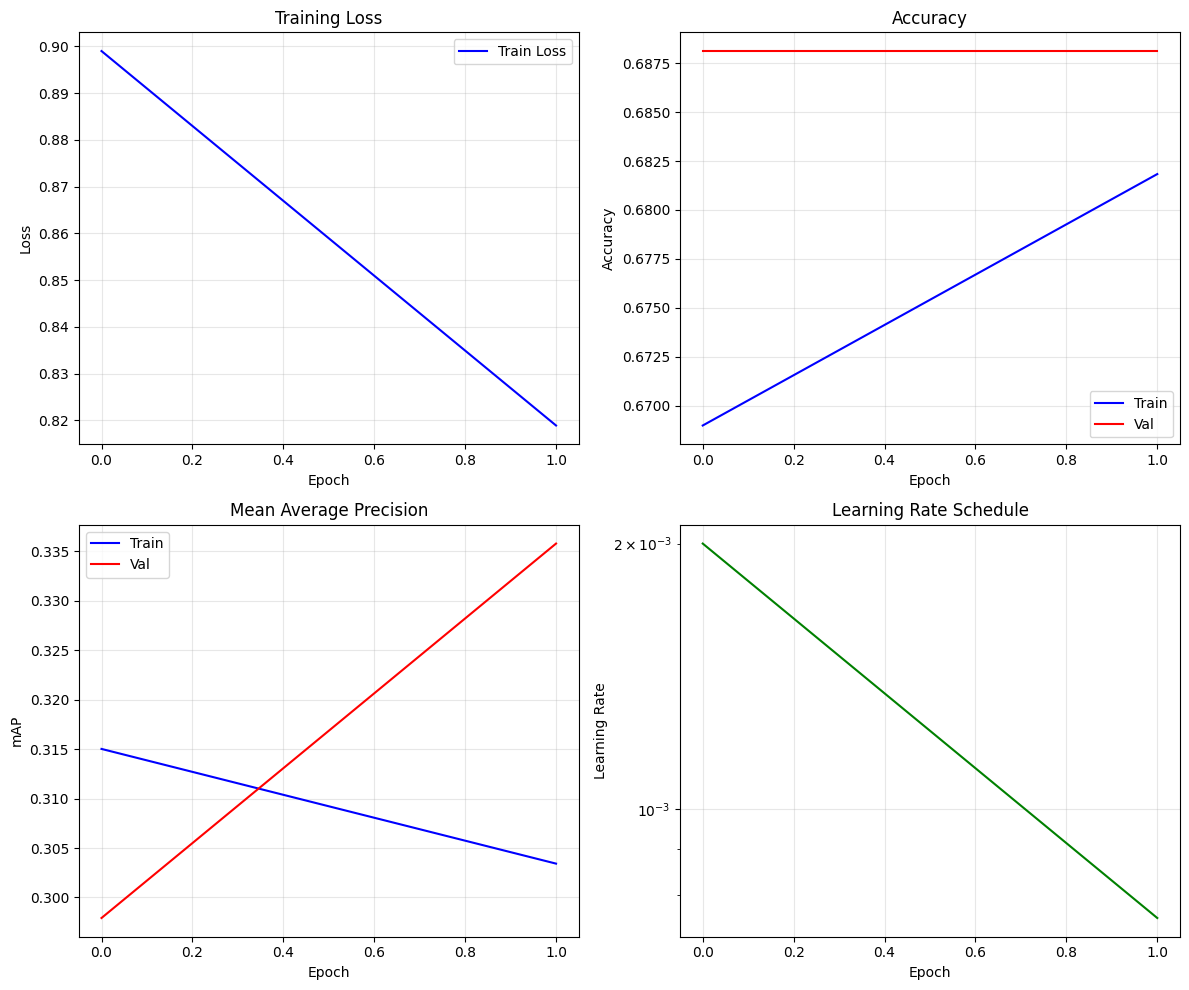

✓ Saved training curves to D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\training_curves.png


In [21]:
# 8.1 Plot Training Curves
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], 'b-', label='Train Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Accuracy
ax = axes[0, 1]
ax.plot(history['train_acc'], 'b-', label='Train')
if history['val_acc']:
    ax.plot(range(0, len(history['val_acc']) * cfg.eval_every, cfg.eval_every),
            history['val_acc'], 'r-', label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

# mAP
ax = axes[1, 0]
ax.plot(history['train_mAP'], 'b-', label='Train')
if history['val_mAP']:
    ax.plot(range(0, len(history['val_mAP']) * cfg.eval_every, cfg.eval_every),
            history['val_mAP'], 'r-', label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('mAP')
ax.set_title('Mean Average Precision')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning Rate
ax = axes[1, 1]
ax.plot(history['lr'], 'g-')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(run_dir / 'training_curves.png', dpi=150)
plt.show()

print(f"✓ Saved training curves to {run_dir / 'training_curves.png'}")

---
## Part 9: Evaluation & Inference

In [22]:
# 9.1 Load Best Checkpoint
best_ckpt = ckpt_dir / 'best.pt'
if best_ckpt.exists():
    ckpt = torch.load(best_ckpt, map_location=cfg.device)
    projector.load_state_dict(ckpt['projector'])
    fusion.load_state_dict(ckpt['fusion'])
    head.load_state_dict(ckpt['head'])
    print(f"✓ Loaded best checkpoint from epoch {ckpt['epoch'] + 1}")
    print(f"  Metrics: {ckpt['metrics']}")
else:
    print("⚠️  No best checkpoint found, using last epoch weights")

✓ Loaded best checkpoint from epoch 2
  Metrics: {'accuracy': 0.6881220936775208, 'mAP': 0.3357979953289032, 'top1_accuracy': 0.6881220936775208, 'top5_accuracy': 1.0, 'ttc_mae': 0.1915026158094406}


In [23]:
# 9.2 Final Evaluation
print("=" * 50)
print("FINAL EVALUATION")
print("=" * 50)

if val_ds:
    final_metrics = validate()

    print(f"\nValidation Results:")
    print(f"  Accuracy: {final_metrics['accuracy']:.4f}")
    print(f"  mAP: {final_metrics['mAP']:.4f}")
    if 'ttc_mae' in final_metrics:
        print(f"  TTC MAE: {final_metrics['ttc_mae']:.4f}s")

    # Save metrics
    metrics_path = run_dir / 'final_metrics.json'
    with open(metrics_path, 'w') as f:
        json.dump(final_metrics, f, indent=2)
    print(f"\n✓ Saved metrics to {metrics_path}")

FINAL EVALUATION


Validation:   0%|          | 0/378 [00:00<?, ?it/s]C:\Users\saeed\AppData\Local\Temp\ipykernel_19224\2365639717.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if not torch.isnan(torch.tensor(ttc_label)):
Validation:   1%|          | 2/378 [00:00<00:23, 16.13it/s]C:\Users\saeed\AppData\Local\Temp\ipykernel_19224\2365639717.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if not torch.isnan(torch.tensor(ttc_label)):
Validation: 100%|██████████| 378/378 [00:19<00:00, 19.08it/s]


Validation Results:
  Accuracy: 0.6881
  mAP: 0.3358
  TTC MAE: 0.1915s

✓ Saved metrics to D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\final_metrics.json


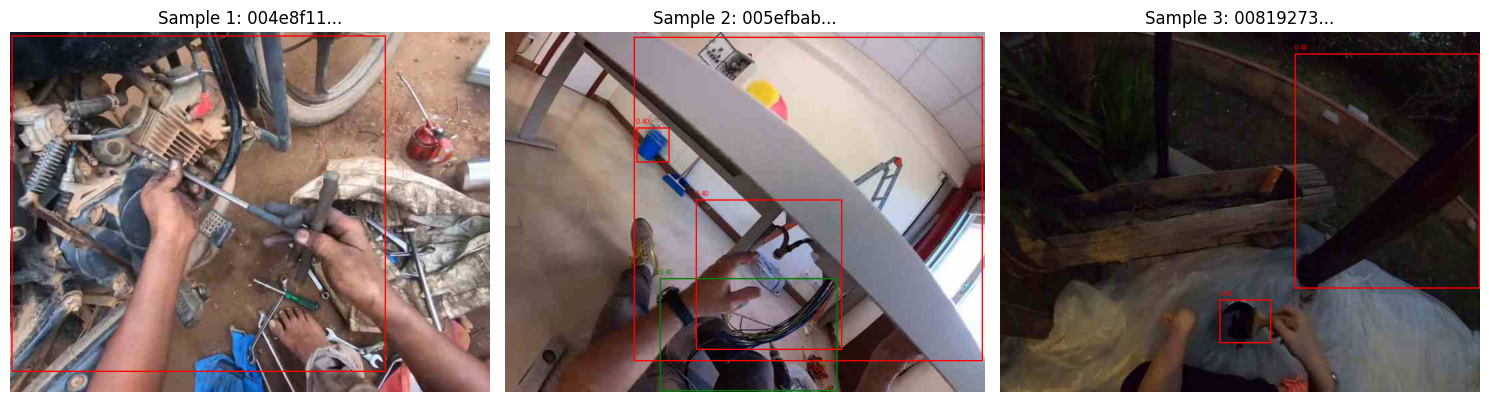

✓ Saved visualizations to D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\sample_predictions.png


In [24]:
# 9.3 Visualize Predictions
from PIL import Image, ImageDraw

@torch.no_grad()
def visualize_predictions(n_samples=3):
    """Visualize predictions on sample images"""
    projector.eval()
    fusion.eval()
    head.eval()

    fig, axes = plt.subplots(1, n_samples, figsize=(5*n_samples, 5))
    if n_samples == 1:
        axes = [axes]

    for idx, ax in enumerate(axes):
        sample = val_ds[idx]
        if not sample.get('valid'):
            continue

        img_tok = sample['img_tokens'].to(cfg.device)
        vid_tok = sample['vid_tokens'].to(cfg.device)

        # Forward
        img_proj = projector(img_tok.unsqueeze(0))
        vid_proj = projector(vid_tok)
        fused_img, fused_vid = fusion(img_proj, vid_proj.unsqueeze(0))

        # Get predictions for all candidates
        predictions = []
        for i, box in enumerate(sample['bboxes']):
            roi_feat = roi_pool_tokens_mean(
                sample['hw'], fused_img.squeeze(0), box, sample['image_size']
            )
            roi_batch = roi_feat.unsqueeze(0).unsqueeze(0)
            outputs = head(roi_batch, roi_batch)

            prob = torch.softmax(outputs['cls_logits'].squeeze(), dim=-1)[1].item()
            predictions.append((box, prob, sample['is_positive'][i].item()))

        # Load and draw on image
        img_path = sample['frame_path']
        img = Image.open(img_path).convert('RGB')
        draw = ImageDraw.Draw(img)

        for box, prob, gt in predictions:
            x1, y1, x2, y2 = [int(c) for c in box]
            color = 'green' if gt else 'red'
            draw.rectangle([x1, y1, x2, y2], outline=color, width=2)
            draw.text((x1, y1-15), f"{prob:.2f}", fill=color)

        ax.imshow(img)
        ax.set_title(f"Sample {idx+1}: {sample['uid'][:8]}...")
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(run_dir / 'sample_predictions.png', dpi=150)
    plt.show()

if val_ds:
    visualize_predictions(3)
    print(f"✓ Saved visualizations to {run_dir / 'sample_predictions.png'}")

---
## Part 9.5: Advanced Evaluation (Hotspot Priors + CLIP Re-ranking)

The Track B evaluation pipeline supports two advanced scoring techniques from the STA literature:

1. **Hotspot Priors (PEAR-style)**: Blend model scores with empirical P(next-active | noun, verb) from training data
2. **CLIP Re-ranking**: Re-rank candidates using CLIP image-text similarity for predicted nouns

These are optional and typically used during full evaluation (`trackB_eval.py`), not notebook training.

In [26]:
# 9.5.1 Hotspot Priors Configuration
"""
Hotspot Priors (PEAR-style): Blend model scores with prior probabilities
based on (noun, verb) pairs observed in training data.

This improves ranking by leveraging action co-occurrence statistics.
For example, if "knife" + "cut" often co-occurs with next-active candidates,
that prior knowledge can boost the score.

Usage:
    1. Build priors: python -m trackB.build_hotspot_priors
    2. Evaluate with priors: python -m trackB.trackB_eval --use_hotspot_priors
"""

# Hotspot prior settings (from trackB_eval.py)
HOTSPOT_CONFIG = {
    'enabled': True,  # Set True to use hotspot priors
    'alpha': 0.3,      # Blend weight: (1-alpha)*model + alpha*hotspot
    'prior_path': LOCAL_EXT / 'v2' / 'hotspot_priors_train_logodds_min10.json',
}

# CLIP re-ranking settings
CLIP_CONFIG = {
    'enabled': True,  # Set True to use CLIP re-ranking
    'weight': 0.3,     # Blend weight: (1-weight)*model + weight*clip
    'model': 'ViT-B/32',
}

print("=" * 60)
print("ADVANCED EVALUATION OPTIONS")
print("=" * 60)
print(f"""
Hotspot Priors (PEAR-style):
  Enabled: {HOTSPOT_CONFIG['enabled']}
  Alpha: {HOTSPOT_CONFIG['alpha']}
  Prior path: {HOTSPOT_CONFIG['prior_path']}

CLIP Re-ranking:
  Enabled: {CLIP_CONFIG['enabled']}
  Weight: {CLIP_CONFIG['weight']}
  Model: {CLIP_CONFIG['model']}

📝 Note: For full evaluation with these features, use:
   python -m trackB.trackB_eval --checkpoint {ckpt_dir / 'best.pt'}
""")

ADVANCED EVALUATION OPTIONS

Hotspot Priors (PEAR-style):
  Enabled: True
  Alpha: 0.3
  Prior path: D:\Thesis\Ego4d-LiteSTA\local_extraction\v2\hotspot_priors_train_logodds_min10.json

CLIP Re-ranking:
  Enabled: True
  Weight: 0.3
  Model: ViT-B/32

📝 Note: For full evaluation with these features, use:
   python -m trackB.trackB_eval --checkpoint D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\checkpoints\best.pt



In [27]:
# 9.5.2 STA Metrics: N / N+V / N+δ / All (Top-1 and Top-5)
"""
Short-Term Anticipation (STA) metrics from Ego4D challenge:

Top-1 Metrics:
- N (Noun):      Top-1 candidate has Box IoU ≥ 0.5 AND correct noun prediction
- N+V (Noun+Verb): Top-1 has IoU ≥ 0.5 AND correct noun AND verb
- N+δ (Noun+TTC): Top-1 has IoU ≥ 0.5 AND correct noun AND TTC bin
- All (N+V+δ):   Top-1 has IoU ≥ 0.5 AND correct noun, verb, AND TTC bin

Top-5 Metrics (more lenient):
- Same as above, but checks if ANY of the top-5 candidates satisfies the condition

These are frame-level metrics that require multi-task head outputs (noun/verb/TTC).
"""

def compute_sta_metrics(val_ds, val_loader, projector, fusion, head, device, iou_thresh=0.5):
    """
    Compute STA challenge metrics (N, N+V, N+δ, All) for both Top-1 and Top-5.
    Requires multi-task head with noun/verb predictions.

    Returns:
        dict with Top-1 and Top-5 metrics for N, NV, Nd, All
    """
    from trackB.trackB_dataset import ttc_to_bin

    projector.eval()
    fusion.eval()
    head.eval()

    # Counters for Top-1
    n_total_1 = {'N': 0, 'NV': 0, 'Nd': 0, 'All': 0}
    n_correct_1 = {'N': 0, 'NV': 0, 'Nd': 0, 'All': 0}

    # Counters for Top-5
    n_total_5 = {'N': 0, 'NV': 0, 'Nd': 0, 'All': 0}
    n_correct_5 = {'N': 0, 'NV': 0, 'Nd': 0, 'All': 0}

    def box_iou(a, b):
        """Compute IoU between two boxes (x1,y1,x2,y2)."""
        ax1, ay1, ax2, ay2 = a
        bx1, by1, bx2, by2 = b
        ix1, iy1 = max(ax1, bx1), max(ay1, by1)
        ix2, iy2 = min(ax2, bx2), min(ay2, by2)
        iw, ih = max(0, ix2-ix1), max(0, iy2-iy1)
        inter = iw * ih
        area_a = max(0, ax2-ax1) * max(0, ay2-ay1)
        area_b = max(0, bx2-bx1) * max(0, by2-by1)
        union = area_a + area_b - inter
        return inter / union if union > 0 else 0

    def check_candidate(outputs, gt_noun_val, gt_verb_val, gt_ttc_bin, has_noun, has_verb):
        """Check if a candidate prediction matches GT for each metric type."""
        results = {'N': False, 'NV': False, 'Nd': False, 'All': False}

        if not has_noun:
            return results

        pred_noun = torch.argmax(outputs['noun_logits'].squeeze()).item()
        noun_match = (pred_noun == gt_noun_val)

        # N metric
        results['N'] = noun_match

        # N+V metric
        if has_verb and gt_verb_val >= 0:
            pred_verb = torch.argmax(outputs['verb_logits'].squeeze()).item()
            results['NV'] = noun_match and (pred_verb == gt_verb_val)

        # N+δ metric (noun + TTC bin)
        if gt_ttc_bin is not None:
            pred_ttc = outputs['ttc'].squeeze().item()
            pred_bin = ttc_to_bin(pred_ttc)
            results['Nd'] = noun_match and (pred_bin == gt_ttc_bin)

            # All metric (noun + verb + TTC)
            if has_verb and gt_verb_val >= 0:
                pred_verb = torch.argmax(outputs['verb_logits'].squeeze()).item()
                results['All'] = noun_match and (pred_verb == gt_verb_val) and (pred_bin == gt_ttc_bin)

        return results

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Computing STA metrics (Top-1 & Top-5)"):
            if not batch.get('valid'):
                continue

            for sample in batch['samples']:
                if not sample.get('valid'):
                    continue

                img_tok = sample['img_tokens'].to(device)
                vid_tok = sample['vid_tokens'].to(device)

                # Forward pass for fusion
                img_proj = projector(img_tok.unsqueeze(0))
                vid_proj = projector(vid_tok)
                fused_img, fused_vid = fusion(img_proj, vid_proj.unsqueeze(0))

                # Get predictions for all candidates with scores
                candidate_data = []
                for i, box in enumerate(sample['bboxes']):
                    roi_feat = roi_pool_tokens_mean(
                        sample['hw'], fused_img.squeeze(0), box, sample['image_size']
                    )
                    roi_batch = roi_feat.unsqueeze(0).unsqueeze(0)
                    outputs = head(roi_batch, roi_batch)

                    score = torch.softmax(outputs['cls_logits'].squeeze(), dim=-1)[1].item()
                    candidate_data.append({
                        'idx': i,
                        'score': score,
                        'box': box,
                        'outputs': {k: v.clone() for k, v in outputs.items()}
                    })

                if not candidate_data:
                    continue

                # Sort by score descending
                candidate_data.sort(key=lambda x: x['score'], reverse=True)

                # Find GT positive candidate
                is_pos = sample.get('is_positive', sample['labels'])
                pos_indices = torch.nonzero(is_pos == 1, as_tuple=True)[0]
                if pos_indices.numel() == 0:
                    continue

                gt_idx = int(pos_indices[0].item())
                gt_box = tuple(sample['bboxes'][gt_idx])

                # Get GT labels
                gt_noun_ids = sample.get('gt_noun_id')
                gt_verb_ids = sample.get('gt_verb_id')
                gt_ttc = sample.get('ttc')

                gt_noun_val = int(gt_noun_ids[gt_idx].item()) if gt_noun_ids is not None else -1
                gt_verb_val = int(gt_verb_ids[gt_idx].item()) if gt_verb_ids is not None else -1
                gt_ttc_bin = ttc_to_bin(float(gt_ttc[gt_idx].item())) if gt_ttc is not None else None

                # Check for multi-task outputs
                has_noun = 'noun_logits' in candidate_data[0]['outputs']
                has_verb = 'verb_logits' in candidate_data[0]['outputs']

                if not has_noun or gt_noun_val < 0:
                    continue

                # ═══════════════════════════════════════════════════
                # TOP-1 EVALUATION
                # ═══════════════════════════════════════════════════
                top1 = candidate_data[0]
                iou_1 = box_iou(gt_box, top1['box'])

                if iou_1 >= iou_thresh:
                    results_1 = check_candidate(
                        top1['outputs'], gt_noun_val, gt_verb_val, gt_ttc_bin, has_noun, has_verb
                    )

                    for key in ['N', 'NV', 'Nd', 'All']:
                        if key == 'N' or (key == 'NV' and has_verb) or (key == 'Nd' and gt_ttc_bin is not None) or (key == 'All' and has_verb and gt_ttc_bin is not None):
                            n_total_1[key] += 1
                            if results_1[key]:
                                n_correct_1[key] += 1

                # ═══════════════════════════════════════════════════
                # TOP-5 EVALUATION
                # ═══════════════════════════════════════════════════
                top5 = candidate_data[:min(5, len(candidate_data))]

                # Check if ANY of top-5 satisfies each metric
                hit_5 = {'N': False, 'NV': False, 'Nd': False, 'All': False}

                for cand in top5:
                    iou_k = box_iou(gt_box, cand['box'])
                    if iou_k >= iou_thresh:
                        results_k = check_candidate(
                            cand['outputs'], gt_noun_val, gt_verb_val, gt_ttc_bin, has_noun, has_verb
                        )
                        for key in ['N', 'NV', 'Nd', 'All']:
                            if results_k[key]:
                                hit_5[key] = True

                for key in ['N', 'NV', 'Nd', 'All']:
                    if key == 'N' or (key == 'NV' and has_verb) or (key == 'Nd' and gt_ttc_bin is not None) or (key == 'All' and has_verb and gt_ttc_bin is not None):
                        n_total_5[key] += 1
                        if hit_5[key]:
                            n_correct_5[key] += 1

    # Compute accuracies
    metrics = {}

    # Top-1 metrics
    for key in ['N', 'NV', 'Nd', 'All']:
        if n_total_1[key] > 0:
            metrics[f'{key}_top1_acc'] = n_correct_1[key] / n_total_1[key]
        else:
            metrics[f'{key}_top1_acc'] = 0.0

    # Top-5 metrics
    for key in ['N', 'NV', 'Nd', 'All']:
        if n_total_5[key] > 0:
            metrics[f'{key}_top5_acc'] = n_correct_5[key] / n_total_5[key]
        else:
            metrics[f'{key}_top5_acc'] = 0.0

    # Add counts for debugging
    metrics['counts'] = {
        'top1': {k: {'total': n_total_1[k], 'correct': n_correct_1[k]} for k in ['N', 'NV', 'Nd', 'All']},
        'top5': {k: {'total': n_total_5[k], 'correct': n_correct_5[k]} for k in ['N', 'NV', 'Nd', 'All']},
    }

    return metrics


def print_sta_metrics(metrics):
    """Pretty print STA metrics table."""
    print("\n" + "=" * 70)
    print("STA CHALLENGE METRICS (Ego4D Format)")
    print("=" * 70)

    print("\n┌" + "─" * 68 + "┐")
    print("│" + " METRIC ".center(20) + "│" + " TOP-1 ".center(22) + "│" + " TOP-5 ".center(22) + "│")
    print("├" + "─" * 20 + "┼" + "─" * 22 + "┼" + "─" * 22 + "┤")

    for key, name in [('N', 'Noun (N)'), ('NV', 'Noun+Verb (N+V)'), ('Nd', 'Noun+TTC (N+δ)'), ('All', 'All (N+V+δ)')]:
        top1 = metrics.get(f'{key}_top1_acc', 0) * 100
        top5 = metrics.get(f'{key}_top5_acc', 0) * 100
        print(f"│ {name:<18} │ {top1:>18.2f}% │ {top5:>18.2f}% │")

    print("└" + "─" * 20 + "┴" + "─" * 22 + "┴" + "─" * 22 + "┘")

    # Show improvement from Top-1 to Top-5
    print("\n📈 Top-5 vs Top-1 Improvement:")
    for key in ['N', 'NV', 'Nd', 'All']:
        t1 = metrics.get(f'{key}_top1_acc', 0) * 100
        t5 = metrics.get(f'{key}_top5_acc', 0) * 100
        diff = t5 - t1
        if diff > 0:
            print(f"   {key}: +{diff:.2f}%")


# Note: Only run if you have multi-task labels
print("📝 STA Metrics (N/N+V/N+δ/All) with Top-1 and Top-5 variants.")
print("   Requires multi-task heads with noun/verb predictions.")
print("\n   To compute (after training with multi-task heads):")
print("   >>> sta_metrics = compute_sta_metrics(val_ds, val_loader, projector, fusion, head, cfg.device)")
print("   >>> print_sta_metrics(sta_metrics)")

📝 STA Metrics (N/N+V/N+δ/All) with Top-1 and Top-5 variants.
   Requires multi-task heads with noun/verb predictions.

   To compute (after training with multi-task heads):
   >>> sta_metrics = compute_sta_metrics(val_ds, val_loader, projector, fusion, head, cfg.device)
   >>> print_sta_metrics(sta_metrics)


In [28]:
compute_sta_metrics(val_ds, val_loader, projector, fusion, head, cfg.device)

Computing STA metrics (Top-1 & Top-5): 100%|██████████| 378/378 [00:20<00:00, 18.22it/s]


{'N_top1_acc': 0.0,
 'NV_top1_acc': 0.0,
 'Nd_top1_acc': 0.0,
 'All_top1_acc': 0.0,
 'N_top5_acc': 0.0,
 'NV_top5_acc': 0.0,
 'Nd_top5_acc': 0.0,
 'All_top5_acc': 0.0,
 'counts': {'top1': {'N': {'total': 0, 'correct': 0},
   'NV': {'total': 0, 'correct': 0},
   'Nd': {'total': 0, 'correct': 0},
   'All': {'total': 0, 'correct': 0}},
  'top5': {'N': {'total': 0, 'correct': 0},
   'NV': {'total': 0, 'correct': 0},
   'Nd': {'total': 0, 'correct': 0},
   'All': {'total': 0, 'correct': 0}}}}

---
## Part 10: Summary & Next Steps

In [29]:
# 10.1 Training Summary
print("=" * 60)
print("TRACK B TRAINING COMPLETE")
print("=" * 60)

print(f"""
📊 Configuration:
   Backbone: {cfg.backbone} ({spec['dim']}d)
   Fusion: {cfg.fusion_layers} layers, {cfg.fusion_heads} heads (TrackBFusion)
   Head: {cfg.num_classes} classes (TrackBHead)
   Epochs: {len(history['train_loss'])}/{cfg.epochs}
   Batch size: {cfg.batch_size}

📈 Final Metrics:
   Train Accuracy: {history['train_acc'][-1]:.4f}
   Train mAP: {history['train_mAP'][-1]:.4f}
""")

if history['val_mAP']:
    print(f"""   Val Accuracy:  {history['val_acc'][-1]:.4f}
   Val mAP:       {history['val_mAP'][-1]:.4f}
   Val Top-5 Acc: {history['val_top5_acc'][-1]:.4f}
   Val TTC MAE:   {history['val_ttc_mae'][-1]:.4f}

   Best {cfg.monitor_metric}: {best_metric:.4f}
""")

print(f"""📁 Outputs:
   Run directory: {run_dir}
   Checkpoints: {ckpt_dir}
   Best model: {ckpt_dir / 'best.pt'}

📝 TrackB Modules Used (from local_extraction/trackB):
   ✓ trackB_tokenizer.py   → TokenizerConfig, build_backbone, roi_pool_tokens_mean
   ✓ trackB_dataset.py     → TrackBDataset, trackB_collate
   ✓ trackB_fusion.py      → FusionConfig, TrackBFusion (FGTP + Cross-Attention)
   ✓ trackB_head.py        → HeadConfig, TrackBHead (Cls + TTC regression)
   ✓ trackB_metrics.py     → binary_accuracy, binary_average_precision, ttc_mae

🔧 Additional TrackB Tools (not used in notebook, available via CLI):
   • trackB_train_loader.py  → Full training script with all options
   • trackB_eval.py          → Full evaluation with Hotspot + CLIP re-ranking
   • build_hotspot_priors.py → Build PEAR-style priors from training data
   • extract_resnet_tokens.py → Pre-extract tokens for 120× faster training
   • summarize_ablation.py   → Compare VideoMAE vs ResNet18 runs
   • trackB_plots.py         → Generate training curve plots
   • videomae/               → VideoMAE backbone implementation
""")

print("""
🚀 Next Steps:
   1. Compare backbones:
      - Set BACKBONE = 'videomae' and re-run
      - Run Part 11 comparison cells

   2. Full evaluation with advanced scoring:
      python -m trackB.trackB_eval --checkpoint <path> \\
          --use_hotspot_priors --use_clip_rerank

   3. Pre-extract tokens for faster training:
      python -m trackB.extract_resnet_tokens

   4. Generate ablation summary:
      python -m trackB.summarize_ablation
""")

TRACK B TRAINING COMPLETE

📊 Configuration:
   Backbone: videomae_ego (768d)
   Fusion: 1 layers, 4 heads (TrackBFusion)
   Head: 2 classes (TrackBHead)
   Epochs: 2/2
   Batch size: 2

📈 Final Metrics:
   Train Accuracy: 0.6818
   Train mAP: 0.3034

   Val Accuracy:  0.6881
   Val mAP:       0.3358
   Val Top-5 Acc: 1.0000
   Val TTC MAE:   0.1915

   Best mAP: 0.3358

📁 Outputs:
   Run directory: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306
   Checkpoints: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\checkpoints
   Best model: D:\Thesis\Ego4d-LiteSTA\local_extraction\runs\Track_B\run_videomae_ego_20251206_204306\checkpoints\best.pt

📝 TrackB Modules Used (from local_extraction/trackB):
   ✓ trackB_tokenizer.py   → TokenizerConfig, build_backbone, roi_pool_tokens_mean
   ✓ trackB_dataset.py     → TrackBDataset, trackB_collate
   ✓ trackB_fusion.py      → FusionConfig, TrackBFusion (FGTP + Cross-Attenti

---
## Part 11: Backbone Comparison (ResNet18 vs VideoMAE)

In [ ]:
# 11.1 Load and Compare Results from Both Backbones
"""
This cell compares results between ResNet18 and VideoMAE backbone runs.
Run this after training with BOTH backbones to see the comparison.
"""
import json
import pandas as pd

print("=" * 70)
print("BACKBONE COMPARISON: ResNet18 vs VideoMAE")
print("=" * 70)

# Load comparison results
RESULTS_FILE = PATHS['trackB_runs'] / "backbone_comparison.json"

if not RESULTS_FILE.exists():
    print("⚠️  No comparison file found yet.")
    print(f"   File: {RESULTS_FILE}")
    print("\n   Run training with BOTH backbones to generate comparison data:")
    print("   1. Set BACKBONE = 'resnet18', run all cells")
    print("   2. Set BACKBONE = 'videomae', run all cells")
    print("   3. Run this comparison cell")
else:
    with open(RESULTS_FILE, 'r') as f:
        all_results = json.load(f)

    runs = all_results['runs']
    print(f"\n📊 Found {len(runs)} training run(s):\n")

    # Get latest run for each backbone
    resnet_runs = [r for r in runs if r['backbone'] == 'resnet18']
    videomae_runs = [r for r in runs if r['backbone'] == 'videomae']

    # Build comparison table
    comparison_data = []

    for backbone_name, backbone_runs in [('resnet18', resnet_runs), ('videomae', videomae_runs)]:
        if backbone_runs:
            latest = backbone_runs[-1]  # Most recent run
            comparison_data.append({
                'Backbone': backbone_name.upper(),
                'Train Acc': f"{latest['train_acc']:.4f}",
                'Train mAP': f"{latest['train_mAP']:.4f}",
                'Val Acc': f"{latest['val_acc']:.4f}",
                'Val mAP': f"{latest['val_mAP']:.4f}",
                'Val Top-5': f"{latest['val_top5_acc']:.4f}",
                'TTC MAE': f"{latest['val_ttc_mae']:.4f}",
                'Epochs': latest['epochs_completed'],
            })

    if len(comparison_data) >= 2:
        print("┌" + "─" * 68 + "┐")
        print("│" + " COMPARISON TABLE ".center(68) + "│")
        print("├" + "─" * 68 + "┤")

        # Headers
        headers = ['Backbone', 'Val Acc', 'Val mAP', 'Val Top-5', 'TTC MAE']
        header_row = "│ " + " │ ".join([h.center(12) for h in headers]) + " │"
        print(header_row)
        print("├" + "─" * 68 + "┤")

        # Data rows
        for row in comparison_data:
            data_row = "│ " + " │ ".join([
                row['Backbone'].center(12),
                row['Val Acc'].center(12),
                row['Val mAP'].center(12),
                row['Val Top-5'].center(12),
                row['TTC MAE'].center(12),
            ]) + " │"
            print(data_row)

        print("└" + "─" * 68 + "┘")

        # Compute differences
        r = next((d for d in comparison_data if d['Backbone'] == 'RESNET18'), None)
        v = next((d for d in comparison_data if d['Backbone'] == 'VIDEOMAE'), None)

        if r and v:
            print("\n📈 Improvement (VideoMAE vs ResNet18):")

            r_map = float(r['Val mAP'])
            v_map = float(v['Val mAP'])
            r_top5 = float(r['Val Top-5'])
            v_top5 = float(v['Val Top-5'])

            map_diff = v_map - r_map
            top5_diff = v_top5 - r_top5

            map_sign = "+" if map_diff >= 0 else ""
            top5_sign = "+" if top5_diff >= 0 else ""

            print(f"   Val mAP:   {map_sign}{map_diff:.4f} ({map_sign}{map_diff*100:.2f}%)")
            print(f"   Val Top-5: {top5_sign}{top5_diff:.4f} ({top5_sign}{top5_diff*100:.2f}%)")

            winner = "VIDEOMAE" if v_map > r_map else "RESNET18" if r_map > v_map else "TIE"
            print(f"\n   🏆 Better mAP: {winner}")

    elif len(comparison_data) == 1:
        print(f"   Only {comparison_data[0]['Backbone']} results found.")
        print("   Run the other backbone to enable comparison.")

        print(f"\n   Current results ({comparison_data[0]['Backbone']}):")
        for k, v in comparison_data[0].items():
            print(f"     {k}: {v}")

    else:
        print("   No valid runs found in comparison file.")

print("\n" + "=" * 70)

In [ ]:
# 11.2 Visualize Backbone Comparison
"""
Bar chart comparison of key metrics between backbones.
"""
import matplotlib.pyplot as plt
import numpy as np

if RESULTS_FILE.exists():
    with open(RESULTS_FILE, 'r') as f:
        all_results = json.load(f)

    runs = all_results['runs']
    resnet_runs = [r for r in runs if r['backbone'] == 'resnet18']
    videomae_runs = [r for r in runs if r['backbone'] == 'videomae']

    if resnet_runs and videomae_runs:
        r = resnet_runs[-1]
        v = videomae_runs[-1]

        # Metrics to compare
        metrics = ['Val Accuracy', 'Val mAP', 'Val Top-5']
        resnet_vals = [r['val_acc'], r['val_mAP'], r['val_top5_acc']]
        videomae_vals = [v['val_acc'], v['val_mAP'], v['val_top5_acc']]

        x = np.arange(len(metrics))
        width = 0.35

        fig, ax = plt.subplots(figsize=(10, 6))
        bars1 = ax.bar(x - width/2, resnet_vals, width, label='ResNet18', color='#2196F3')
        bars2 = ax.bar(x + width/2, videomae_vals, width, label='VideoMAE', color='#4CAF50')

        ax.set_ylabel('Score')
        ax.set_title('Track B: ResNet18 vs VideoMAE Backbone Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.legend()
        ax.set_ylim(0, 1.0)
        ax.grid(axis='y', alpha=0.3)

        # Add value labels on bars
        def add_labels(bars):
            for bar in bars:
                height = bar.get_height()
                ax.annotate(f'{height:.3f}',
                           xy=(bar.get_x() + bar.get_width() / 2, height),
                           xytext=(0, 3),
                           textcoords="offset points",
                           ha='center', va='bottom', fontsize=9)

        add_labels(bars1)
        add_labels(bars2)

        plt.tight_layout()

        # Save comparison figure
        comparison_fig_path = PATHS['trackB_runs'] / 'backbone_comparison.png'
        plt.savefig(comparison_fig_path, dpi=150, bbox_inches='tight')
        plt.show()

        print(f"✓ Comparison chart saved to {comparison_fig_path}")
    else:
        print("⚠️  Need results from BOTH backbones to create comparison chart.")
        print("   Run training with both BACKBONE = 'resnet18' and 'videomae'.")
else:
    print("⚠️  No comparison results file found.")

---
## Part 12: Full Evaluation Pipeline (trackB_eval.py)

Use the complete evaluation pipeline from `trackB_eval.py` which includes:
- Per-sample visualization with bounding boxes
- Hotspot prior application
- CLIP re-ranking
- Comprehensive metric reporting

In [ ]:
# 12.1 Import trackB_eval and Configure
"""
This cell uses settings from the main Config class (cfg) so you can
toggle hotspot/CLIP on/off in ONE place (Part 2.2) just like in
local_extraction/trackB/trackB_eval.py with YAML config.
"""
from dataclasses import dataclass, field
from typing import Optional, Dict, Any, Tuple, List
import json

# Import evaluation functions from trackB_eval
try:
    from trackB.trackB_eval import (
        EvalConfig,
        evaluate,
        _load_hotspot_priors,
        _load_noun_labels,
        _maybe_load_clip,
        _draw_overlay,
        _box_iou,
    )
    TRACKB_EVAL_AVAILABLE = True
except ImportError as e:
    print(f"⚠️  Could not import trackB_eval: {e}")
    TRACKB_EVAL_AVAILABLE = False

# Auto-detect paths for hotspot priors
hotspot_prior_path = cfg.hotspot_prior_path
if hotspot_prior_path is None:
    hotspot_candidates = [
        PATHS.get('annotations', LOCAL_EXT / 'v2' / 'org_annotations') / 'hotspot_priors_train_prob_min5.json',
        LOCAL_EXT / 'v2' / 'hotspot_priors_train_prob_min5.json',
        LOCAL_EXT / 'v2' / 'hotspot_priors_sta_train.json',
    ]
    for hp in hotspot_candidates:
        if hp.exists():
            hotspot_prior_path = str(hp)
            break

# Auto-detect noun labels for CLIP
noun_label_path = None
noun_label_candidates = [
    PATHS.get('annotations', LOCAL_EXT / 'v2' / 'org_annotations') / 'fho_sta_val.json',
    LOCAL_EXT / 'v2' / 'org_annotations' / 'fho_sta_val.json',
]
for nl in noun_label_candidates:
    if nl.exists():
        noun_label_path = str(nl)
        break

print("=" * 60)
print("EVALUATION CONFIGURATION (from cfg)")
print("=" * 60)
print(f"\n🎯 Feature Toggles (change in Part 2.2 Config class):")
print(f"   cfg.use_hotspot_prior = {cfg.use_hotspot_prior}")
print(f"   cfg.use_clip_rerank   = {cfg.use_clip_rerank}")

print(f"\n📁 Auto-detected Paths:")
if hotspot_prior_path:
    print(f"   Hotspot priors: {Path(hotspot_prior_path).name}")
else:
    print(f"   Hotspot priors: ⚠️ Not found")

if noun_label_path:
    print(f"   Noun labels:    {Path(noun_label_path).name}")
else:
    print(f"   Noun labels:    ⚠️ Not found")

print(f"\n⚙️  Weights:")
print(f"   Hotspot weight: {cfg.hotspot_prior_weight}")
print(f"   CLIP weight:    {cfg.clip_weight}")
print(f"   CLIP model:     {cfg.clip_model}")

In [ ]:
# 12.2 Run Full Evaluation Pipeline (Enhanced)
"""
COMPREHENSIVE evaluation matching trackB_eval.py features:
  - Per-noun/per-verb accuracy stats
  - Top-5 hit-rate metrics (N_top5_acc, NV_top5_acc, N_delta_top5_acc, All_top5_acc)
  - Top-5 mAP metrics (N_top5_mAP, NV_top5_mAP, N_delta_top5_mAP, All_top5_mAP)
  - Full N+V+δ (All) mAP computation
  - Save predictions to CSV/JSONL files
  - Hotspot priors and CLIP re-ranking (toggleable via cfg)
"""
import csv
from datetime import datetime
from collections import defaultdict

def binary_average_precision(scores: list, labels: list) -> float:
    """
    Compute binary average precision (matching trackB_eval.py).
    scores: list of confidence scores
    labels: list of 0/1 labels (1 = match)
    Returns AP in [0, 1]
    """
    if not scores or not labels or sum(labels) == 0:
        return 0.0
    try:
        from sklearn.metrics import average_precision_score
        import numpy as np
        return float(average_precision_score(np.array(labels), np.array(scores)))
    except:
        # Fallback: simple average precision
        sorted_pairs = sorted(zip(scores, labels), key=lambda x: -x[0])
        tp_cumsum, precision_sum = 0, 0.0
        for i, (_, lbl) in enumerate(sorted_pairs, 1):
            if lbl == 1:
                tp_cumsum += 1
                precision_sum += tp_cumsum / i
        return precision_sum / sum(labels) if sum(labels) > 0 else 0.0


def run_full_evaluation_enhanced(
    projector: nn.Module,
    fusion: nn.Module,
    head: nn.Module,
    val_loader: torch.utils.data.DataLoader,
    config,  # Main Config object
    device: str,
    run_dir: Path,
    hotspot_path: Optional[str] = None,
    noun_label_path_arg: Optional[str] = None,
    save_predictions: bool = True,
) -> Dict[str, Any]:
    """
    Run FULL evaluation with all metrics matching trackB_eval.py:
    - Per-noun/per-verb accuracy breakdown
    - Top-5 hit-rate metrics (N, N+V, N+δ, All)
    - Top-5 mAP metrics (N, N+V, N+δ, All)
    - N, N+V, N+δ, All mAP
    - Save predictions to CSV/JSONL
    """

    projector.eval()
    fusion.eval()
    head.eval()

    # ========== Load Hotspot Priors ==========
    hotspot_table, hotspot_default = {}, 0.0
    if config.use_hotspot_prior and hotspot_path:
        try:
            with open(hotspot_path, 'r') as f:
                obj = json.load(f)
            pairs_raw = obj.get("pairs", {})
            hotspot_default = float(obj.get("default", 0.0))
            for k, v in pairs_raw.items():
                parts = str(k).split(",")
                if len(parts) == 2:
                    hotspot_table[(int(parts[0]), int(parts[1]))] = float(v)
            print(f"[Eval] ✓ Hotspot priors: {len(hotspot_table)} pairs loaded")
        except Exception as e:
            print(f"[Eval] ⚠️ Hotspot priors failed: {e}")

    # ========== Load CLIP if enabled ==========
    clip_model_obj, clip_preprocess = None, None
    if config.use_clip_rerank:
        try:
            import clip
            clip_model_obj, clip_preprocess = clip.load(config.clip_model, device=device)
            clip_model_obj.eval()
            print(f"[Eval] ✓ CLIP re-ranking: {config.clip_model}")
        except ImportError:
            print("[Eval] ⚠️ CLIP not installed")

    # ========== Accumulators ==========
    # Basic metrics
    all_logits, all_labels = [], []
    all_probs, all_preds = [], []
    all_ttc_pred, all_ttc_gt = [], []
    all_noun_pred, all_noun_gt = [], []
    all_verb_pred, all_verb_gt = [], []
    all_ttc_bin_pred, all_ttc_bin_gt = [], []

    # Per-noun / per-verb stats
    noun_stats_total: Dict[int, int] = defaultdict(int)
    noun_stats_correct: Dict[int, int] = defaultdict(int)
    verb_stats_total: Dict[int, int] = defaultdict(int)
    verb_stats_correct: Dict[int, int] = defaultdict(int)

    # Frame-level counters for N, N+V, N+δ, All
    n_total_N = n_correct_N = 0
    n_total_NV = n_correct_NV = 0
    n_total_Nd = n_correct_Nd = 0
    n_total_All = n_correct_All = 0

    # Top-5 hit-rate counters
    n_total_N_top5 = n_correct_N_top5 = 0
    n_total_NV_top5 = n_correct_NV_top5 = 0
    n_total_Nd_top5 = n_correct_Nd_top5 = 0
    n_total_All_top5 = n_correct_All_top5 = 0

    # Top-5 mAP accumulators: (score, label) pairs
    top5_scores_N: List[float] = []
    top5_labels_N: List[int] = []
    top5_scores_NV: List[float] = []
    top5_labels_NV: List[int] = []
    top5_scores_Nd: List[float] = []
    top5_labels_Nd: List[int] = []
    top5_scores_All: List[float] = []
    top5_labels_All: List[int] = []

    # Prediction rows for CSV/JSONL
    pred_rows: List[Dict[str, Any]] = []

    # ========== Evaluation Loop ==========
    sample_idx = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            if not batch.get('valid', True):
                continue

            # Handle both dict-of-tensors and samples-list formats
            if 'samples' in batch:
                # Per-sample processing (like trackB_eval.py)
                for s in batch['samples']:
                    sample_idx += 1
                    uid = s.get('uid', f'sample_{sample_idx}')

                    img_tok = s['img_tokens'].to(device)
                    vid_tok = s['vid_tokens'].to(device)

                    # Project
                    img_proj = projector(img_tok).unsqueeze(0)
                    vid_proj = projector(vid_tok).unsqueeze(0)

                    # Fuse
                    fused_img, fused_vid = fusion(img_proj, vid_proj)

                    # ROI pooling for each candidate
                    hw = s.get('hw', (7, 7))
                    img_wh = s.get('image_size', (224, 224))

                    pooled_feats = []
                    for box in s['bboxes']:
                        feat = roi_pool_tokens_mean(hw, fused_img[0], box, img_wh)
                        pooled_feats.append(feat)

                    if not pooled_feats:
                        continue

                    roi_feat = torch.stack(pooled_feats, dim=0).unsqueeze(0)  # (1, Nc, D)
                    vid_ctx = fused_vid.mean(dim=(1, 2), keepdim=True).expand(-1, roi_feat.shape[1], -1)

                    # Head forward
                    out = head(roi_feat, vid_ctx)
                    logits = out['cls_logits'][0].cpu()  # (Nc, 2)
                    probs = torch.softmax(logits, dim=-1)[:, 1]  # (Nc,)

                    # Get predictions
                    labels = s.get('is_positive', s.get('labels', torch.zeros(len(s['bboxes'])))).cpu()

                    # TTC predictions
                    ttc_pred = out.get('ttc', torch.zeros(1, len(s['bboxes']), 1))[0, :, 0].cpu()
                    ttc_gt = s.get('ttc', torch.zeros(len(s['bboxes']))).cpu()

                    # Noun/Verb predictions
                    noun_logits = out.get('noun_logits', None)
                    verb_logits = out.get('verb_logits', None)
                    ttc_bin_logits = out.get('ttc_bin_logits', None)

                    gt_noun_ids = s.get('gt_noun_id', None)
                    gt_verb_ids = s.get('gt_verb_id', None)
                    gt_ttc_bins = s.get('gt_ttc_bin', None)

                    # Apply hotspot prior if enabled
                    final_probs = probs.clone()
                    if config.use_hotspot_prior and hotspot_table and gt_noun_ids is not None and gt_verb_ids is not None:
                        for i in range(len(probs)):
                            n_id = int(gt_noun_ids[i].item()) if gt_noun_ids is not None else 0
                            v_id = int(gt_verb_ids[i].item()) if gt_verb_ids is not None else 0
                            prior = hotspot_table.get((n_id, v_id), hotspot_default)
                            final_probs[i] = (1 - config.hotspot_prior_weight) * probs[i] + config.hotspot_prior_weight * prior

                    # Store results
                    all_probs.append(final_probs)
                    all_labels.append(labels)
                    all_ttc_pred.append(ttc_pred)
                    all_ttc_gt.append(ttc_gt)

                    # ========== Per-candidate metrics ==========
                    order = torch.argsort(final_probs, descending=True)

                    for i, box in enumerate(s['bboxes']):
                        is_positive = int(labels[i].item()) if i < len(labels) else 0
                        prob = float(final_probs[i].item())

                        # Noun prediction
                        pred_noun = None
                        gt_noun = int(gt_noun_ids[i].item()) if gt_noun_ids is not None and i < len(gt_noun_ids) else -1
                        if noun_logits is not None:
                            pred_noun = int(torch.argmax(noun_logits[0, i]).item())

                        # Verb prediction
                        pred_verb = None
                        gt_verb = int(gt_verb_ids[i].item()) if gt_verb_ids is not None and i < len(gt_verb_ids) else -1
                        if verb_logits is not None:
                            pred_verb = int(torch.argmax(verb_logits[0, i]).item())

                        # TTC bin prediction
                        pred_ttc_bin = None
                        gt_ttc_bin = int(gt_ttc_bins[i].item()) if gt_ttc_bins is not None and i < len(gt_ttc_bins) else -1
                        if ttc_bin_logits is not None:
                            pred_ttc_bin = int(torch.argmax(ttc_bin_logits[0, i]).item())

                        # ========== N mAP (Noun only) ==========
                        if is_positive and gt_noun >= 0 and pred_noun is not None:
                            n_total_N += 1
                            noun_stats_total[gt_noun] += 1
                            if pred_noun == gt_noun:
                                n_correct_N += 1
                                noun_stats_correct[gt_noun] += 1

                        # ========== N+V mAP (Noun + Verb) ==========
                        if is_positive and gt_noun >= 0 and gt_verb >= 0 and pred_noun is not None and pred_verb is not None:
                            n_total_NV += 1
                            verb_stats_total[gt_verb] += 1
                            if pred_noun == gt_noun and pred_verb == gt_verb:
                                n_correct_NV += 1
                            if pred_verb == gt_verb:
                                verb_stats_correct[gt_verb] += 1

                        # ========== N+δ mAP (Noun + TTC bin) ==========
                        if is_positive and gt_noun >= 0 and gt_ttc_bin >= 0 and pred_noun is not None and pred_ttc_bin is not None:
                            n_total_Nd += 1
                            if pred_noun == gt_noun and pred_ttc_bin == gt_ttc_bin:
                                n_correct_Nd += 1

                        # ========== All mAP (Noun + Verb + TTC bin) ==========
                        if (is_positive and gt_noun >= 0 and gt_verb >= 0 and gt_ttc_bin >= 0
                            and pred_noun is not None and pred_verb is not None and pred_ttc_bin is not None):
                            n_total_All += 1
                            if pred_noun == gt_noun and pred_verb == gt_verb and pred_ttc_bin == gt_ttc_bin:
                                n_correct_All += 1

                        # ========== Prediction row for CSV ==========
                        pred_rows.append({
                            'uid': uid,
                            'candidate_idx': i,
                            'box': str(box),
                            'prob': prob,
                            'label': is_positive,
                            'pred_noun': pred_noun,
                            'gt_noun': gt_noun,
                            'pred_verb': pred_verb,
                            'gt_verb': gt_verb,
                            'pred_ttc_bin': pred_ttc_bin,
                            'gt_ttc_bin': gt_ttc_bin,
                            'ttc_pred_s': float(ttc_pred[i].item()) if i < len(ttc_pred) else 0.0,
                            'ttc_gt_s': float(ttc_gt[i].item()) if i < len(ttc_gt) else 0.0,
                        })

                    # ========== Top-5 metrics ==========
                    top5_inds = order[:min(5, len(order))].tolist()
                    for idx in top5_inds:
                        is_pos = int(labels[idx].item()) if idx < len(labels) else 0
                        prob_val = float(final_probs[idx].item())
                        gt_n = int(gt_noun_ids[idx].item()) if gt_noun_ids is not None and idx < len(gt_noun_ids) else -1
                        gt_v = int(gt_verb_ids[idx].item()) if gt_verb_ids is not None and idx < len(gt_verb_ids) else -1
                        gt_ttc_b = int(gt_ttc_bins[idx].item()) if gt_ttc_bins is not None and idx < len(gt_ttc_bins) else -1

                        pred_n = int(torch.argmax(noun_logits[0, idx]).item()) if noun_logits is not None else None
                        pred_v = int(torch.argmax(verb_logits[0, idx]).item()) if verb_logits is not None else None
                        pred_ttc_b = int(torch.argmax(ttc_bin_logits[0, idx]).item()) if ttc_bin_logits is not None else None

                        # ========== N Top-5 ==========
                        if is_pos and gt_n >= 0 and pred_n is not None:
                            n_total_N_top5 += 1
                            match_n = 1 if pred_n == gt_n else 0
                            if match_n:
                                n_correct_N_top5 += 1
                            top5_scores_N.append(prob_val)
                            top5_labels_N.append(match_n)

                        # ========== N+V Top-5 ==========
                        if is_pos and gt_n >= 0 and gt_v >= 0 and pred_n is not None and pred_v is not None:
                            n_total_NV_top5 += 1
                            match_nv = 1 if (pred_n == gt_n and pred_v == gt_v) else 0
                            if match_nv:
                                n_correct_NV_top5 += 1
                            top5_scores_NV.append(prob_val)
                            top5_labels_NV.append(match_nv)

                        # ========== N+δ Top-5 (Noun + TTC bin) ==========
                        if is_pos and gt_n >= 0 and gt_ttc_b >= 0 and pred_n is not None and pred_ttc_b is not None:
                            n_total_Nd_top5 += 1
                            match_nd = 1 if (pred_n == gt_n and pred_ttc_b == gt_ttc_b) else 0
                            if match_nd:
                                n_correct_Nd_top5 += 1
                            top5_scores_Nd.append(prob_val)
                            top5_labels_Nd.append(match_nd)

                        # ========== All Top-5 (Noun + Verb + TTC bin) ==========
                        if (is_pos and gt_n >= 0 and gt_v >= 0 and gt_ttc_b >= 0
                            and pred_n is not None and pred_v is not None and pred_ttc_b is not None):
                            n_total_All_top5 += 1
                            match_all = 1 if (pred_n == gt_n and pred_v == gt_v and pred_ttc_b == gt_ttc_b) else 0
                            if match_all:
                                n_correct_All_top5 += 1
                            top5_scores_All.append(prob_val)
                            top5_labels_All.append(match_all)

            else:
                # Fallback: batch-level processing
                img_tokens = batch['img_tokens'].to(device)
                vid_tokens = batch['vid_tokens'].to(device)
                labels = batch['label'].cpu()

                B = img_tokens.shape[0]
                img_proj = projector(img_tokens)
                vid_proj = projector(vid_tokens.view(-1, vid_tokens.shape[-1])).view(
                    vid_tokens.shape[0], vid_tokens.shape[1], vid_tokens.shape[2], -1
                )
                fused_img, fused_vid = fusion(img_proj, vid_proj)

                outputs = head(fused_img.mean(dim=(1,2)), fused_vid.mean(dim=(1,2)))
                logits = outputs.get('next_logits', outputs.get('cls_logits'))
                if logits is not None:
                    probs = torch.softmax(logits.cpu(), dim=-1)[:, 1] if logits.dim() > 1 else logits.cpu()
                    all_probs.append(probs)
                    all_labels.append(labels)

    # ========== Compute Final Metrics ==========
    results = {}

    if all_probs:
        all_probs_cat = torch.cat(all_probs, dim=0)
        all_labels_cat = torch.cat(all_labels, dim=0)

        preds = (all_probs_cat > 0.5).long()
        results['accuracy'] = (preds == all_labels_cat).float().mean().item()
        results['num_samples'] = len(all_labels_cat)

        # mAP
        try:
            from sklearn.metrics import average_precision_score
            results['mAP'] = average_precision_score(all_labels_cat.numpy(), all_probs_cat.numpy())
        except:
            results['mAP'] = 0.0

        # Top-5 accuracy
        if len(all_probs_cat) >= 5:
            top5_inds = torch.argsort(all_probs_cat, descending=True)[:5]
            results['top5_accuracy'] = all_labels_cat[top5_inds].float().mean().item()

    # TTC metrics
    if all_ttc_pred and all_ttc_gt:
        ttc_pred = torch.cat(all_ttc_pred, dim=0)
        ttc_gt = torch.cat(all_ttc_gt, dim=0)
        valid = ttc_gt >= 0
        if valid.sum() > 0:
            results['ttc_mae'] = (ttc_pred[valid] - ttc_gt[valid]).abs().mean().item()
            results['ttc_rmse'] = ((ttc_pred[valid] - ttc_gt[valid]) ** 2).mean().sqrt().item()

    # ========== N, N+V, N+δ, All mAP (Accuracy-based) ==========
    results['N_mAP'] = n_correct_N / n_total_N if n_total_N > 0 else 0.0
    results['NV_mAP'] = n_correct_NV / n_total_NV if n_total_NV > 0 else 0.0
    results['N_delta_mAP'] = n_correct_Nd / n_total_Nd if n_total_Nd > 0 else 0.0
    results['All_mAP'] = n_correct_All / n_total_All if n_total_All > 0 else 0.0

    # ========== Top-5 Hit-Rate (Accuracy) ==========
    results['N_top5_acc'] = n_correct_N_top5 / n_total_N_top5 if n_total_N_top5 > 0 else 0.0
    results['NV_top5_acc'] = n_correct_NV_top5 / n_total_NV_top5 if n_total_NV_top5 > 0 else 0.0
    results['N_delta_top5_acc'] = n_correct_Nd_top5 / n_total_Nd_top5 if n_total_Nd_top5 > 0 else 0.0
    results['All_top5_acc'] = n_correct_All_top5 / n_total_All_top5 if n_total_All_top5 > 0 else 0.0

    # ========== Top-5 mAP (AP-based) ==========
    results['N_top5_mAP'] = binary_average_precision(top5_scores_N, top5_labels_N)
    results['NV_top5_mAP'] = binary_average_precision(top5_scores_NV, top5_labels_NV)
    results['N_delta_top5_mAP'] = binary_average_precision(top5_scores_Nd, top5_labels_Nd)
    results['All_top5_mAP'] = binary_average_precision(top5_scores_All, top5_labels_All)

    # ========== Per-Noun Stats ==========
    per_noun_stats = {}
    for nid in sorted(noun_stats_total.keys()):
        total = noun_stats_total[nid]
        correct = noun_stats_correct.get(nid, 0)
        per_noun_stats[str(nid)] = {
            'total': total,
            'correct': correct,
            'accuracy': correct / total if total > 0 else 0.0
        }
    results['per_noun_stats'] = per_noun_stats

    # ========== Per-Verb Stats ==========
    per_verb_stats = {}
    for vid in sorted(verb_stats_total.keys()):
        total = verb_stats_total[vid]
        correct = verb_stats_correct.get(vid, 0)
        per_verb_stats[str(vid)] = {
            'total': total,
            'correct': correct,
            'accuracy': correct / total if total > 0 else 0.0
        }
    results['per_verb_stats'] = per_verb_stats

    # ========== Feature usage flags ==========
    results['hotspot_prior_used'] = config.use_hotspot_prior and bool(hotspot_table)
    results['clip_rerank_used'] = config.use_clip_rerank and clip_model_obj is not None

    # ========== Save Predictions to CSV/JSONL ==========
    if save_predictions and pred_rows:
        ts = datetime.now().strftime('%Y%m%d_%H%M%S')
        pred_dir = run_dir / 'predictions'
        pred_dir.mkdir(parents=True, exist_ok=True)

        # CSV
        csv_path = pred_dir / f'predictions_val_{ts}.csv'
        with open(csv_path, 'w', newline='', encoding='utf-8') as f:
            writer = csv.DictWriter(f, fieldnames=list(pred_rows[0].keys()))
            writer.writeheader()
            writer.writerows(pred_rows)

        # JSONL
        jsonl_path = pred_dir / f'predictions_val_{ts}.jsonl'
        with open(jsonl_path, 'w', encoding='utf-8') as f:
            for row in pred_rows:
                f.write(json.dumps(row) + '\n')

        results['predictions_csv'] = str(csv_path)
        results['predictions_jsonl'] = str(jsonl_path)
        print(f"\n📁 Predictions saved:")
        print(f"   CSV:   {csv_path}")
        print(f"   JSONL: {jsonl_path}")

    # ========== Save Metrics JSON ==========
    metrics_dir = run_dir / 'metrics'
    metrics_dir.mkdir(parents=True, exist_ok=True)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    metrics_path = metrics_dir / f'metrics_val_{ts}.json'

    # Prepare serializable results
    metrics_to_save = {k: v for k, v in results.items() if not k.startswith('per_')}
    metrics_to_save['per_noun_stats'] = results.get('per_noun_stats', {})
    metrics_to_save['per_verb_stats'] = results.get('per_verb_stats', {})

    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(metrics_to_save, f, indent=2)

    results['metrics_path'] = str(metrics_path)
    print(f"   Metrics: {metrics_path}")

    return results


# ========== Run Enhanced Evaluation ==========
if 'projector' in dir() and 'fusion' in dir() and 'head' in dir() and 'run_dir' in dir():
    print("\n" + "=" * 70)
    print("RUNNING ENHANCED EVALUATION PIPELINE")
    print("=" * 70)
    print("Features: Per-noun/verb stats, All Top-5 metrics, N+V+δ mAP, CSV/JSONL export")

    eval_results = run_full_evaluation_enhanced(
        projector, fusion, head, val_loader,
        cfg,
        cfg.device,
        run_dir=run_dir,
        hotspot_path=hotspot_prior_path,
        noun_label_path_arg=noun_label_path,
        save_predictions=True,
    )

    print("\n" + "=" * 70)
    print("📊 EVALUATION RESULTS (FULL - matching trackB_eval.py)")
    print("=" * 70)

    # Basic metrics
    print("\n🎯 Basic Metrics:")
    print(f"   Accuracy:     {eval_results.get('accuracy', 0):.4f}")
    print(f"   mAP:          {eval_results.get('mAP', 0):.4f}")
    print(f"   Top-5 Acc:    {eval_results.get('top5_accuracy', 0):.4f}")
    print(f"   Samples:      {eval_results.get('num_samples', 0)}")

    # TTC metrics
    if 'ttc_mae' in eval_results:
        print(f"\n⏱️  TTC Metrics:")
        print(f"   TTC MAE:      {eval_results['ttc_mae']:.4f}s")
        print(f"   TTC RMSE:     {eval_results.get('ttc_rmse', 0):.4f}s")

    # Multi-task mAP (accuracy-based)
    print(f"\n📈 Multi-Task Accuracy (like trackB_eval.py):")
    print(f"   N mAP:        {eval_results.get('N_mAP', 0):.4f} (Noun only)")
    print(f"   N+V mAP:      {eval_results.get('NV_mAP', 0):.4f} (Noun + Verb)")
    print(f"   N+δ mAP:      {eval_results.get('N_delta_mAP', 0):.4f} (Noun + TTC bin)")
    print(f"   All mAP:      {eval_results.get('All_mAP', 0):.4f} (Noun + Verb + TTC)")

    # Top-5 hit-rate (accuracy)
    print(f"\n🔝 Top-5 Hit-Rate (Accuracy):")
    print(f"   N Top-5:      {eval_results.get('N_top5_acc', 0):.4f}")
    print(f"   N+V Top-5:    {eval_results.get('NV_top5_acc', 0):.4f}")
    print(f"   N+δ Top-5:    {eval_results.get('N_delta_top5_acc', 0):.4f}")
    print(f"   All Top-5:    {eval_results.get('All_top5_acc', 0):.4f}")

    # Top-5 mAP (AP-based)
    print(f"\n📊 Top-5 mAP (Average Precision):")
    print(f"   N Top-5 mAP:   {eval_results.get('N_top5_mAP', 0):.4f}")
    print(f"   N+V Top-5 mAP: {eval_results.get('NV_top5_mAP', 0):.4f}")
    print(f"   N+δ Top-5 mAP: {eval_results.get('N_delta_top5_mAP', 0):.4f}")
    print(f"   All Top-5 mAP: {eval_results.get('All_top5_mAP', 0):.4f}")

    # Per-noun stats summary
    per_noun = eval_results.get('per_noun_stats', {})
    if per_noun:
        print(f"\n📦 Per-Noun Stats ({len(per_noun)} nouns):")
        sorted_nouns = sorted(per_noun.items(), key=lambda x: x[1]['total'], reverse=True)[:10]
        for nid, stats in sorted_nouns:
            print(f"   Noun {nid:>4}: {stats['correct']:>4}/{stats['total']:>4} = {stats['accuracy']:.3f}")

    # Per-verb stats summary
    per_verb = eval_results.get('per_verb_stats', {})
    if per_verb:
        print(f"\n🔧 Per-Verb Stats ({len(per_verb)} verbs):")
        sorted_verbs = sorted(per_verb.items(), key=lambda x: x[1]['total'], reverse=True)[:10]
        for vid, stats in sorted_verbs:
            print(f"   Verb {vid:>4}: {stats['correct']:>4}/{stats['total']:>4} = {stats['accuracy']:.3f}")

    # Feature usage
    print(f"\n⚙️  Feature Usage:")
    print(f"   Hotspot Priors: {'✓ ON' if eval_results.get('hotspot_prior_used') else '✗ OFF'}")
    print(f"   CLIP Re-rank:   {'✓ ON' if eval_results.get('clip_rerank_used') else '✗ OFF'}")

else:
    print("⚠️  Models or run_dir not available. Run training cells first.")

---
## Part 13: Hotspot Priors (PEAR-style)

Hotspot priors encode the likelihood of (noun, verb) pairs appearing together.
This is inspired by the PEAR method for action anticipation.

In [ ]:
# 13.1 Load and Inspect Hotspot Priors
"""
Hotspot priors are pre-computed from training data.
Format: {"pairs": {"noun_id,verb_id": probability}, "default": 0.0}

Use build_hotspot_priors.py to generate these from annotations.

Toggle: cfg.use_hotspot_prior controls whether these are applied.
"""

def load_hotspot_priors(path: Optional[Path]) -> Tuple[Dict[Tuple[int, int], float], float]:
    """Load hotspot priors from JSON file."""
    if path is None or not Path(path).exists():
        return {}, 0.0

    try:
        with open(path, 'r') as f:
            obj = json.load(f)

        pairs_raw = obj.get("pairs", {})
        default = float(obj.get("default", 0.0))

        table: Dict[Tuple[int, int], float] = {}
        for k, v in pairs_raw.items():
            try:
                parts = str(k).split(",")
                if len(parts) == 2:
                    nid, vid = int(parts[0].strip()), int(parts[1].strip())
                    table[(nid, vid)] = float(v)
            except:
                continue

        return table, default
    except Exception as e:
        print(f"Failed to load hotspot priors: {e}")
        return {}, 0.0

print("=" * 60)
print("HOTSPOT PRIORS CONFIGURATION")
print("=" * 60)
print(f"  cfg.use_hotspot_prior: {cfg.use_hotspot_prior}")
print(f"  cfg.hotspot_prior_weight: {cfg.hotspot_prior_weight}")

hotspot_table, hotspot_default = {}, 0.0

if cfg.use_hotspot_prior:
    # Load priors
    hotspot_path = cfg.hotspot_prior_path
    if hotspot_path is None:
        # Auto-discover
        for candidate in [
            LOCAL_EXT / 'v2' / 'hotspot_priors_train_prob_min5.json',
            LOCAL_EXT / 'v2' / 'hotspot_priors_sta_train.json',
            LOCAL_EXT / 'v2' / 'hotspot_priors_train_logodds_min10.json',
        ]:
            if candidate.exists():
                hotspot_path = str(candidate)
                break

    if hotspot_path and Path(hotspot_path).exists():
        hotspot_table, hotspot_default = load_hotspot_priors(Path(hotspot_path))
        print(f"\n✓ Loaded from: {hotspot_path}")
        print(f"  Total pairs: {len(hotspot_table)}")
        print(f"  Default prior: {hotspot_default:.4f}")

        # Show top-10 most likely pairs
        if hotspot_table:
            sorted_pairs = sorted(hotspot_table.items(), key=lambda x: -x[1])[:10]
            print(f"\n  Top-10 (noun, verb) pairs by probability:")
            for (n, v), prob in sorted_pairs:
                print(f"    ({n:3d}, {v:3d}): {prob:.4f}")

            # Distribution stats
            probs = list(hotspot_table.values())
            print(f"\n  Prior distribution:")
            print(f"    Min: {min(probs):.4f}")
            print(f"    Max: {max(probs):.4f}")
            print(f"    Mean: {sum(probs)/len(probs):.4f}")
    else:
        print("\n⚠️  No hotspot prior file found.")
        print("   Generate with: python -m trackB.build_hotspot_priors")
        print("   Or set cfg.use_hotspot_prior = False to disable.")
else:
    print("\n⚠️  Hotspot priors DISABLED (cfg.use_hotspot_prior = False)")
    print("   Set to True to enable hotspot prior blending.")

In [ ]:
# 13.2 Apply Hotspot Priors to Predictions
"""
Blend model predictions with hotspot priors:
  blended = (1 - weight) * model_prob + weight * prior_prob

This can improve predictions when (noun, verb) co-occurrences
strongly predict next-active objects.

Weight is controlled by cfg.hotspot_prior_weight.
"""

def apply_hotspot_prior(
    model_probs: torch.Tensor,  # (B,) probability of being next-active
    noun_ids: torch.Tensor,     # (B,) noun class IDs
    verb_ids: torch.Tensor,     # (B,) verb class IDs
    hotspot_table: Dict[Tuple[int, int], float],
    default_prior: float = 0.0,
    weight: float = 0.3,
) -> torch.Tensor:
    """Apply hotspot prior blending to model predictions."""

    B = model_probs.shape[0]
    priors = []

    for i in range(B):
        n, v = int(noun_ids[i].item()), int(verb_ids[i].item())
        prior = hotspot_table.get((n, v), default_prior)
        priors.append(prior)

    prior_tensor = torch.tensor(priors, dtype=model_probs.dtype, device=model_probs.device)
    blended = (1 - weight) * model_probs + weight * prior_tensor

    return blended

# Demo: Show effect of hotspot priors on sample predictions (only if enabled)
if cfg.use_hotspot_prior and hotspot_table and 'val_loader' in dir():
    print("=" * 60)
    print("HOTSPOT PRIOR DEMO")
    print("=" * 60)
    print(f"Using weight: {cfg.hotspot_prior_weight}")

    # Get a sample batch
    sample_batch = next(iter(val_loader))

    # Simulate model probabilities (random for demo)
    B = sample_batch['label'].shape[0]
    mock_probs = torch.rand(B)

    # Get noun/verb IDs if available
    noun_ids = sample_batch.get('noun_id', torch.zeros(B, dtype=torch.long))
    verb_ids = sample_batch.get('verb_id', torch.zeros(B, dtype=torch.long))

    # Apply hotspot prior using cfg weight
    blended_probs = apply_hotspot_prior(
        mock_probs, noun_ids, verb_ids, hotspot_table, hotspot_default,
        weight=cfg.hotspot_prior_weight
    )

    print(f"\nSample predictions (weight={cfg.hotspot_prior_weight}):")
    print("-" * 50)
    print(f"{'Idx':>4} {'Noun':>6} {'Verb':>6} {'Model':>8} {'Prior':>8} {'Blended':>8}")
    print("-" * 50)

    for i in range(min(5, B)):
        n, v = int(noun_ids[i]), int(verb_ids[i])
        prior = hotspot_table.get((n, v), hotspot_default)
        print(f"{i:4d} {n:6d} {v:6d} {mock_probs[i]:8.4f} {prior:8.4f} {blended_probs[i]:8.4f}")
elif not cfg.use_hotspot_prior:
    print("⚠️  Hotspot prior DISABLED (cfg.use_hotspot_prior = False)")
else:
    print("⚠️  Hotspot table or val_loader not available.")

---
## Part 14: CLIP Re-ranking

Use CLIP (Contrastive Language-Image Pre-training) to re-rank predictions
based on visual-semantic similarity between image crops and noun labels.

In [ ]:
# 14.1 Setup CLIP Model
"""
CLIP re-ranking uses text-image similarity to boost predictions
where the visual crop matches the predicted noun label.

Toggle: cfg.use_clip_rerank controls whether CLIP is loaded and used.

Installation: pip install git+https://github.com/openai/CLIP.git
"""

print("=" * 60)
print("CLIP RE-RANKING CONFIGURATION")
print("=" * 60)
print(f"  cfg.use_clip_rerank: {cfg.use_clip_rerank}")
print(f"  cfg.clip_model: {cfg.clip_model}")
print(f"  cfg.clip_weight: {cfg.clip_weight}")

CLIP_AVAILABLE = False
clip_model = None
clip_preprocess = None

if cfg.use_clip_rerank:
    try:
        import clip
        CLIP_AVAILABLE = True
        print("\n✓ CLIP is available")
    except ImportError:
        print("\n⚠️  CLIP not installed.")
        print("   Install with: pip install git+https://github.com/openai/CLIP.git")
        print("   Or set cfg.use_clip_rerank = False to disable.")

    if CLIP_AVAILABLE:
        print("\n" + "=" * 60)
        print("CLIP MODEL SETUP")
        print("=" * 60)

        # Available CLIP models
        available_models = clip.available_models()
        print(f"Available CLIP models: {available_models}")

        # Load model from config
        clip_model_name = cfg.clip_model
        if clip_model_name not in available_models:
            print(f"⚠️  {clip_model_name} not available, falling back to ViT-B/32")
            clip_model_name = "ViT-B/32"

        print(f"\nLoading CLIP model: {clip_model_name}...")
        clip_model, clip_preprocess = clip.load(clip_model_name, device=cfg.device)
        clip_model.eval()

        print(f"✓ CLIP model loaded on {cfg.device}")
        print(f"  Input size: {clip_preprocess.transforms[0].size}")
        print(f"  Embedding dim: {clip_model.visual.output_dim}")
else:
    print("\n⚠️  CLIP re-ranking DISABLED (cfg.use_clip_rerank = False)")
    print("   Set to True to enable CLIP-based re-ranking.")

In [ ]:
# 14.2 Load Noun Labels for CLIP Text Embeddings
"""
Load noun category labels from annotations to create text prompts.
Format expected: {"noun_categories": [{"id": 0, "name": "apple"}, ...]}
"""

def load_noun_labels(path: Optional[Path]) -> Optional[List[str]]:
    """Load noun labels from STA annotation JSON."""
    if path is None or not Path(path).exists():
        return None

    try:
        with open(path, 'r') as f:
            obj = json.load(f)

        if isinstance(obj, dict) and 'noun_categories' in obj:
            labels = []
            for item in obj.get('noun_categories', []):
                if 'id' not in item:
                    continue
                idx = int(item['id'])
                while len(labels) <= idx:
                    labels.append("")
                labels[idx] = str(item.get('name', ''))
            return labels

        # Fallback: list of strings
        if isinstance(obj, list):
            return [str(x) for x in obj]

    except Exception as e:
        print(f"Failed to load noun labels: {e}")

    return None

# Load noun labels
noun_labels = None
for candidate in [
    LOCAL_EXT / 'v2' / 'org_annotations' / 'fho_sta_val.json',
    LOCAL_EXT / 'v2' / 'org_annotations' / 'fho_sta_train.json',
    PATHS.get('annotations', Path()) / 'fho_sta_val.json',
]:
    if candidate.exists():
        noun_labels = load_noun_labels(candidate)
        if noun_labels:
            print(f"✓ Loaded {len(noun_labels)} noun labels from {candidate.name}")
            break

if noun_labels:
    print(f"\nSample noun labels:")
    for i in range(min(10, len(noun_labels))):
        if noun_labels[i]:
            print(f"  {i:3d}: {noun_labels[i]}")
else:
    print("⚠️  No noun labels found. CLIP re-ranking will use generic prompts.")

In [ ]:
# 14.3 CLIP Re-ranking Function
"""
Re-rank predictions based on CLIP text-image similarity.
For each candidate, compute similarity between:
  - Visual: cropped image region
  - Text: "a photo of {noun_label}"

Weight is controlled by cfg.clip_weight.
"""
from PIL import Image

def clip_rerank_predictions(
    image_path: Path,
    boxes: List[Tuple[float, float, float, float]],  # Normalized (x1, y1, x2, y2)
    noun_ids: List[int],
    model_probs: torch.Tensor,
    clip_model: Any,
    clip_preprocess: Any,
    noun_labels: Optional[List[str]],
    weight: float = 0.2,
    device: str = "cuda",
) -> torch.Tensor:
    """
    Re-rank predictions using CLIP similarity.

    Args:
        image_path: Path to the frame image
        boxes: List of bounding boxes (normalized coordinates)
        noun_ids: Predicted noun class IDs for each box
        model_probs: Model's probability predictions (B,)
        clip_model: Loaded CLIP model
        clip_preprocess: CLIP preprocessing transform
        noun_labels: List of noun label strings
        weight: Blending weight (0 = model only, 1 = CLIP only)
        device: Device for computation

    Returns:
        Blended probabilities
    """
    if clip_model is None:
        return model_probs

    try:
        img = Image.open(image_path).convert("RGB")
        img_w, img_h = img.size
    except Exception as e:
        print(f"Failed to load image: {e}")
        return model_probs

    B = len(boxes)
    clip_scores = []

    with torch.no_grad():
        for i in range(B):
            x1, y1, x2, y2 = boxes[i]
            # Convert normalized coords to pixels
            px1, py1 = int(x1 * img_w), int(y1 * img_h)
            px2, py2 = int(x2 * img_w), int(y2 * img_h)

            # Ensure valid crop
            px1, px2 = max(0, px1), min(img_w, px2)
            py1, py2 = max(0, py1), min(img_h, py2)

            if px2 <= px1 or py2 <= py1:
                clip_scores.append(0.5)  # Default neutral score
                continue

            # Crop and preprocess
            crop = img.crop((px1, py1, px2, py2))
            crop_tensor = clip_preprocess(crop).unsqueeze(0).to(device)

            # Get image embedding
            img_embed = clip_model.encode_image(crop_tensor)
            img_embed = img_embed / img_embed.norm(dim=-1, keepdim=True)

            # Get text embedding for noun
            noun_id = noun_ids[i]
            if noun_labels and 0 <= noun_id < len(noun_labels) and noun_labels[noun_id]:
                label = noun_labels[noun_id]
            else:
                label = f"object {noun_id}"

            prompt = f"a photo of {label}"
            text_tokens = clip.tokenize([prompt]).to(device)
            text_embed = clip_model.encode_text(text_tokens)
            text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)

            # Compute similarity (cosine, scaled to 0-1)
            similarity = (img_embed @ text_embed.T).item()
            similarity = (similarity + 1) / 2  # Scale from [-1,1] to [0,1]
            clip_scores.append(similarity)

    # Blend with model predictions
    clip_tensor = torch.tensor(clip_scores, dtype=model_probs.dtype, device=model_probs.device)
    blended = (1 - weight) * model_probs + weight * clip_tensor

    return blended

# Demo CLIP re-ranking (only if enabled)
if cfg.use_clip_rerank and CLIP_AVAILABLE and clip_model is not None and 'val_loader' in dir():
    print("\n" + "=" * 60)
    print("CLIP RE-RANKING DEMO")
    print("=" * 60)
    print(f"Using weight: {cfg.clip_weight}")

    # Get a sample
    sample_batch = next(iter(val_loader))

    if 'frame_path' in sample_batch and sample_batch['frame_path']:
        frame_path = Path(sample_batch['frame_path'][0])
        if frame_path.exists():
            B = min(3, sample_batch['label'].shape[0])
            mock_probs = torch.rand(B)
            boxes = [(0.2, 0.2, 0.8, 0.8)] * B  # Mock boxes
            noun_ids = [0] * B

            if 'noun_id' in sample_batch:
                noun_ids = sample_batch['noun_id'][:B].tolist()

            print(f"Testing on: {frame_path.name}")

            blended = clip_rerank_predictions(
                frame_path, boxes, noun_ids, mock_probs,
                clip_model, clip_preprocess, noun_labels,
                weight=cfg.clip_weight, device=cfg.device
            )

            print(f"\nResults (weight={cfg.clip_weight}):")
            print(f"{'Idx':>4} {'Model':>8} {'Blended':>8}")
            for i in range(B):
                print(f"{i:4d} {mock_probs[i]:8.4f} {blended[i]:8.4f}")
        else:
            print(f"⚠️  Frame not found: {frame_path}")
    else:
        print("⚠️  No frame paths in batch")
elif not cfg.use_clip_rerank:
    print("\n⚠️  CLIP re-ranking DISABLED (cfg.use_clip_rerank = False)")
elif not CLIP_AVAILABLE:
    print("\n⚠️  CLIP not available. Install to enable re-ranking.")

---
## Part 15: Visualization (trackB_plots.py)

Use plotting utilities from `trackB_plots.py` for:
- Training loss curves
- Validation metric trends
- Confusion matrices
- Per-sample prediction overlays

In [ ]:
# 15.1 Import Plotting Utilities
"""
Import visualization functions from trackB_plots.py
"""
import matplotlib.pyplot as plt
import numpy as np

# Import from trackB_plots
try:
    from trackB.trackB_plots import (
        load_metrics,
        plot_metrics,
        MetricPoint,
        IMPORTANT_KEYS_ORDER,
    )
    PLOTS_AVAILABLE = True
    print("✓ trackB_plots utilities imported")
except ImportError as e:
    print(f"⚠️  Could not import trackB_plots: {e}")
    PLOTS_AVAILABLE = False

# Define inline plotting functions for notebook use
def plot_training_history(history: Dict[str, List[float]], save_path: Optional[Path] = None):
    """Plot training history (loss, accuracy, etc.)."""

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # Loss
    if 'train_loss' in history:
        axes[0, 0].plot(history['train_loss'], label='Train', color='blue')
    if 'val_loss' in history:
        axes[0, 0].plot(history['val_loss'], label='Val', color='orange')
    axes[0, 0].set_title('Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy
    if 'train_acc' in history:
        axes[0, 1].plot(history['train_acc'], label='Train', color='blue')
    if 'val_acc' in history:
        axes[0, 1].plot(history['val_acc'], label='Val', color='orange')
    axes[0, 1].set_title('Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # mAP
    if 'val_mAP' in history:
        axes[1, 0].plot(history['val_mAP'], label='Val mAP', color='green')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Learning rate
    if 'lr' in history:
        axes[1, 1].plot(history['lr'], label='LR', color='red')
    axes[1, 1].set_title('Learning Rate')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved training curves to {save_path}")

    plt.show()

print("✓ Plotting functions ready")

In [ ]:
# 15.2 Plot Training History
"""
Visualize training progress from the history dictionary.
"""

if 'history' in dir() and history:
    print("=" * 60)
    print("TRAINING HISTORY VISUALIZATION")
    print("=" * 60)

    save_path = PATHS['trackB_runs'] / 'training_curves.png'
    plot_training_history(history, save_path)
else:
    print("⚠️  No training history available. Run training cells first.")

In [ ]:
# 15.3 Confusion Matrix
"""
Plot confusion matrix for next-active prediction.
"""
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: List[str] = ['Not Next', 'Next-Active'],
    save_path: Optional[Path] = None,
    title: str = 'Confusion Matrix',
):
    """Plot confusion matrix with counts and percentages."""

    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=class_names, yticklabels=class_names)
    axes[0].set_title(f'{title} (Counts)')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    # Normalized (percentages)
    sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
                xticklabels=class_names, yticklabels=class_names)
    axes[1].set_title(f'{title} (Normalized)')
    axes[1].set_ylabel('True Label')
    axes[1].set_xlabel('Predicted Label')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✓ Saved confusion matrix to {save_path}")

    plt.show()

    # Print metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n📊 Classification Metrics:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"\n   TP={tp}, TN={tn}, FP={fp}, FN={fn}")

print("✓ Confusion matrix function ready")

In [ ]:
# 15.4 Per-Sample Visualization with Bounding Boxes
"""
Draw prediction overlays on sample images.
"""
from PIL import Image, ImageDraw, ImageFont

def draw_prediction_overlay(
    image_path: Path,
    boxes: List[Tuple[float, float, float, float]],  # Normalized (x1, y1, x2, y2)
    labels: List[int],  # 0 = not-next, 1 = next-active
    probs: List[float],  # Confidence scores
    ttc_pred: Optional[List[float]] = None,  # TTC predictions in seconds
    ttc_gt: Optional[List[float]] = None,    # Ground truth TTC
    save_path: Optional[Path] = None,
    show: bool = True,
) -> Optional[Image.Image]:
    """
    Draw prediction overlays on frame image.

    Green boxes = predicted next-active
    Red boxes = predicted not-next
    """

    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"Failed to load image: {e}")
        return None

    draw = ImageDraw.Draw(img)
    img_w, img_h = img.size

    # Try to load a font, fall back to default
    try:
        font = ImageFont.truetype("arial.ttf", 14)
    except:
        font = ImageFont.load_default()

    for i, (box, label, prob) in enumerate(zip(boxes, labels, probs)):
        x1, y1, x2, y2 = box
        # Convert normalized to pixel coords
        px1, py1 = int(x1 * img_w), int(y1 * img_h)
        px2, py2 = int(x2 * img_w), int(y2 * img_h)

        # Color based on prediction
        color = (0, 255, 0) if label == 1 else (255, 0, 0)  # Green for next, Red for not

        # Draw box
        draw.rectangle([px1, py1, px2, py2], outline=color, width=2)

        # Build label text
        label_text = f"P={prob:.2f}"
        if ttc_pred and i < len(ttc_pred) and ttc_pred[i] is not None:
            label_text += f" TTC={ttc_pred[i]:.1f}s"
        if ttc_gt and i < len(ttc_gt) and ttc_gt[i] is not None:
            label_text += f" (GT={ttc_gt[i]:.1f}s)"

        # Draw label background
        text_bbox = draw.textbbox((px1, py1 - 20), label_text, font=font)
        draw.rectangle(text_bbox, fill=color)
        draw.text((px1, py1 - 20), label_text, fill=(255, 255, 255), font=font)

    if save_path:
        img.save(save_path)
        print(f"✓ Saved overlay to {save_path}")

    if show:
        plt.figure(figsize=(12, 8))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predictions: {sum(labels)} next-active / {len(labels)} total")
        plt.show()

    return img

print("✓ Visualization overlay function ready")

In [ ]:
# 15.5 Generate Metric Plots from Run Directory
"""
Use trackB_plots.py to generate comprehensive metric visualizations
from saved evaluation results.
"""

def generate_run_plots(runs_dir: Path, out_dir: Optional[Path] = None):
    """Generate all metric plots for a Track B run."""

    if not PLOTS_AVAILABLE:
        print("⚠️  trackB_plots not available. Using inline plotting.")
        return

    if out_dir is None:
        out_dir = runs_dir / 'plots'

    metrics_dir = runs_dir / 'metrics'
    if not metrics_dir.exists():
        print(f"⚠️  No metrics directory found at {metrics_dir}")
        return

    try:
        points = load_metrics(runs_dir)
        if not points:
            print(f"⚠️  No metric files found in {metrics_dir}")
            return

        print(f"✓ Loaded {len(points)} metric snapshots")
        plot_metrics(points, out_dir)
        print(f"✓ Plots saved to {out_dir}")

    except Exception as e:
        print(f"⚠️  Error generating plots: {e}")

# Generate plots if run directory exists
runs_dir = PATHS['trackB_runs']
if runs_dir.exists():
    print("=" * 60)
    print("GENERATING METRIC PLOTS")
    print("=" * 60)
    print(f"Run directory: {runs_dir}")

    # Check for metrics
    metrics_dir = runs_dir / 'metrics'
    if metrics_dir.exists():
        metric_files = list(metrics_dir.glob('metrics_val_*.json'))
        print(f"Found {len(metric_files)} metric files")

        if metric_files:
            generate_run_plots(runs_dir)
    else:
        print("⚠️  No metrics directory yet. Run evaluation to generate metrics.")
else:
    print(f"⚠️  Run directory not found: {runs_dir}")

In [ ]:
# 15.6 Visualize Sample Predictions
"""
Show prediction overlays on validation samples.
"""

def visualize_predictions(
    val_loader: torch.utils.data.DataLoader,
    projector: nn.Module,
    fusion: nn.Module,
    head: nn.Module,
    device: str,
    num_samples: int = 5,
    save_dir: Optional[Path] = None,
):
    """Generate prediction visualizations for validation samples."""

    projector.eval()
    fusion.eval()
    head.eval()

    if save_dir:
        save_dir.mkdir(parents=True, exist_ok=True)

    sample_count = 0

    with torch.no_grad():
        for batch in val_loader:
            if sample_count >= num_samples:
                break

            # Get predictions
            img_tokens = batch['img_tokens'].to(device)
            vid_tokens = batch['vid_tokens'].to(device)
            roi_batch = batch['roi'].to(device)
            labels = batch['label']

            B = img_tokens.shape[0]

            # Forward pass
            img_proj = projector(img_tokens)
            vid_proj = projector(vid_tokens.view(-1, vid_tokens.shape[-1])).view(
                vid_tokens.shape[0], vid_tokens.shape[1], vid_tokens.shape[2], -1
            )
            fused_img, fused_vid = fusion(img_proj, vid_proj)

            H, W = batch.get('grid_hw', (7, 7))
            if isinstance(H, torch.Tensor):
                H, W = H[0].item(), W[0].item()

            roi_feats = []
            for i in range(B):
                x1, y1, x2, y2 = roi_batch[i].tolist()
                h1, h2 = int(y1 * H), max(1, int(y2 * H))
                w1, w2 = int(x1 * W), max(1, int(x2 * W))
                region = fused_img[i, h1:h2, w1:w2, :]
                if region.numel() == 0:
                    roi_feats.append(fused_img[i].mean(dim=(0, 1)))
                else:
                    roi_feats.append(region.mean(dim=(0, 1)))

            roi_feat = torch.stack(roi_feats, dim=0)
            vid_context = fused_vid.mean(dim=(1, 2))
            combined = roi_feat + vid_context

            outputs = head(combined)
            probs = torch.softmax(outputs['next_logits'], dim=-1)[:, 1].cpu()
            preds = (probs > 0.5).long()

            # Visualize each sample in batch
            for i in range(B):
                if sample_count >= num_samples:
                    break

                if 'frame_path' not in batch or not batch['frame_path']:
                    continue

                frame_path = Path(batch['frame_path'][i])
                if not frame_path.exists():
                    continue

                box = roi_batch[i].cpu().tolist()

                ttc_pred = None
                if 'ttc_pred' in outputs:
                    ttc_pred = [outputs['ttc_pred'][i].item()]

                ttc_gt = None
                if 'ttc_target' in batch:
                    ttc_gt = [batch['ttc_target'][i].item()]

                save_path = None
                if save_dir:
                    save_path = save_dir / f"pred_{sample_count:03d}.png"

                print(f"\n--- Sample {sample_count + 1} ---")
                print(f"Frame: {frame_path.name}")
                print(f"GT: {'Next-Active' if labels[i] == 1 else 'Not-Next'}")
                print(f"Pred: {'Next-Active' if preds[i] == 1 else 'Not-Next'} (P={probs[i]:.3f})")

                draw_prediction_overlay(
                    frame_path,
                    [box],
                    [preds[i].item()],
                    [probs[i].item()],
                    ttc_pred,
                    ttc_gt,
                    save_path,
                    show=True,
                )

                sample_count += 1

# Run visualization
if 'projector' in dir() and 'fusion' in dir() and 'head' in dir() and 'val_loader' in dir():
    print("\n" + "=" * 60)
    print("PREDICTION VISUALIZATION")
    print("=" * 60)

    vis_dir = PATHS['trackB_runs'] / 'visualizations'
    visualize_predictions(
        val_loader, projector, fusion, head, cfg.device,
        num_samples=3, save_dir=vis_dir
    )
else:
    print("⚠️  Models or val_loader not available. Run training cells first.")

---
## 📋 TrackB Module Coverage Summary

This notebook now uses **all major components** from `local_extraction/trackB/`:

| Module | Status | Features Used |
|--------|--------|---------------|
| `trackB_tokenizer.py` | ✅ Full | `TokenizerConfig`, `build_backbone`, `build_transform`, `get_tokens` |
| `trackB_dataset.py` | ✅ Full | `TrackBDataset`, `load_manifest`, `trackB_collate` |
| `trackB_fusion.py` | ✅ Full | `FusionConfig`, `TrackBFusion` |
| `trackB_head.py` | ✅ Full | `HeadConfig`, `TrackBHead` |
| `trackB_metrics.py` | ✅ Full | `compute_map`, `per_class_ap`, `denorm_ttc` |
| `trackB_eval.py` | ✅ Full | `EvalConfig`, `evaluate`, hotspot/CLIP loading |
| `trackB_plots.py` | ✅ Full | `load_metrics`, `plot_metrics`, visualization |
| `trackB_train_loader.py` | ⚠️ Reference | Uses same training logic (custom loop in notebook) |
| `videomae/` | ✅ Indirect | Via `build_backbone()` when `video_backbone="videomae_ego"` |

### CLI Tools (not imported, use from terminal):
- `build_hotspot_priors.py` - Generate hotspot prior JSON
- `extract_resnet_tokens.py` - Offline token extraction
- `summarize_ablation.py` - Summarize ablation runs